In [104]:
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from warnings import filterwarnings

filterwarnings('ignore')

apple_stock_data = yf.download(tickers='AAPL', start='2024-01-01')
apple_stock_data

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2024-01-02 00:00:00+00:00,184.734985,185.639999,188.440002,183.889999,187.149994,82488700
2024-01-03 00:00:00+00:00,183.351761,184.250000,185.880005,183.429993,184.220001,58414500
2024-01-04 00:00:00+00:00,181.023163,181.910004,183.089996,180.880005,182.149994,71983600
2024-01-05 00:00:00+00:00,180.296722,181.179993,182.759995,180.169998,181.990005,62303300
2024-01-08 00:00:00+00:00,184.655365,185.559998,185.600006,181.500000,182.089996,59144500
...,...,...,...,...,...,...
2024-11-11 00:00:00+00:00,224.229996,224.229996,225.699997,221.500000,225.000000,42005600
2024-11-12 00:00:00+00:00,224.229996,224.229996,225.589996,223.360001,224.550003,40398300


In [105]:
apple_stock_data.index

DatetimeIndex(['2024-01-02 00:00:00+00:00', '2024-01-03 00:00:00+00:00',
               '2024-01-04 00:00:00+00:00', '2024-01-05 00:00:00+00:00',
               '2024-01-08 00:00:00+00:00', '2024-01-09 00:00:00+00:00',
               '2024-01-10 00:00:00+00:00', '2024-01-11 00:00:00+00:00',
               '2024-01-12 00:00:00+00:00', '2024-01-16 00:00:00+00:00',
               ...
               '2024-11-04 00:00:00+00:00', '2024-11-05 00:00:00+00:00',
               '2024-11-06 00:00:00+00:00', '2024-11-07 00:00:00+00:00',
               '2024-11-08 00:00:00+00:00', '2024-11-11 00:00:00+00:00',
               '2024-11-12 00:00:00+00:00', '2024-11-13 00:00:00+00:00',
               '2024-11-14 00:00:00+00:00', '2024-11-15 00:00:00+00:00'],
              dtype='datetime64[ns, UTC]', name='Date', length=222, freq=None)

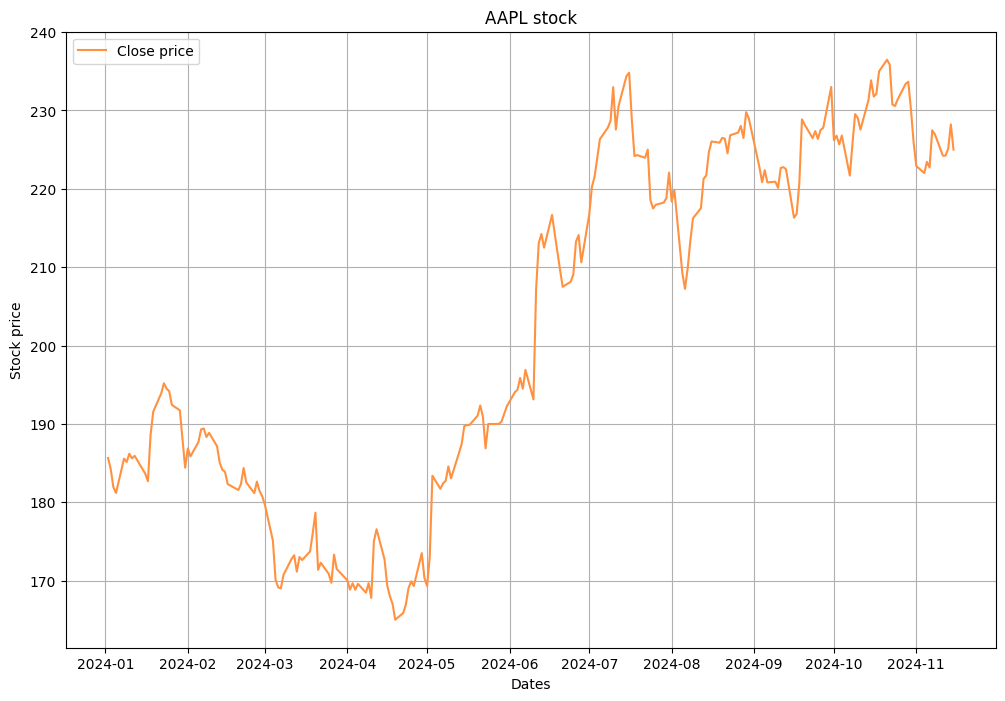

In [106]:
plt.figure(figsize=(12,8))
plt.plot(apple_stock_data.index, apple_stock_data['Close'], label='Close price', color = '#ff9140')
plt.title('AAPL stock')
plt.xlabel('Dates')
plt.ylabel('Stock price')
plt.legend()
plt.grid(True)
plt.show()

# Classical timeseries decomposition

In [107]:
additive_decomposition = seasonal_decompose(x=apple_stock_data['Close'], model='additive', period=30)
additive_decomposition

In [108]:
trend_additive = additive_decomposition.trend
seasonal_additive = additive_decomposition.seasonal
residual_additive = additive_decomposition.resid

trend_additive, seasonal_additive, residual_additive

(Date
 2024-01-02 00:00:00+00:00   NaN
 2024-01-03 00:00:00+00:00   NaN
 2024-01-04 00:00:00+00:00   NaN
 2024-01-05 00:00:00+00:00   NaN
 2024-01-08 00:00:00+00:00   NaN
                              ..
 2024-11-11 00:00:00+00:00   NaN
 2024-11-12 00:00:00+00:00   NaN
 2024-11-13 00:00:00+00:00   NaN
 2024-11-14 00:00:00+00:00   NaN
 2024-11-15 00:00:00+00:00   NaN
 Name: trend, Length: 222, dtype: float64,
 Date
 2024-01-02 00:00:00+00:00   -2.043874
 2024-01-03 00:00:00+00:00   -0.817542
 2024-01-04 00:00:00+00:00   -0.941596
 2024-01-05 00:00:00+00:00   -0.989933
 2024-01-08 00:00:00+00:00    0.258239
                                ...   
 2024-11-11 00:00:00+00:00    3.330044
 2024-11-12 00:00:00+00:00    1.832239
 2024-11-13 00:00:00+00:00    2.263234
 2024-11-14 00:00:00+00:00    3.203735
 2024-11-15 00:00:00+00:00    1.121379
 Name: seasonal, Length: 222, dtype: float64,
 Date
 2024-01-02 00:00:00+00:00   NaN
 2024-01-03 00:00:00+00:00   NaN
 2024-01-04 00:00:00+00:00   NaN
 2

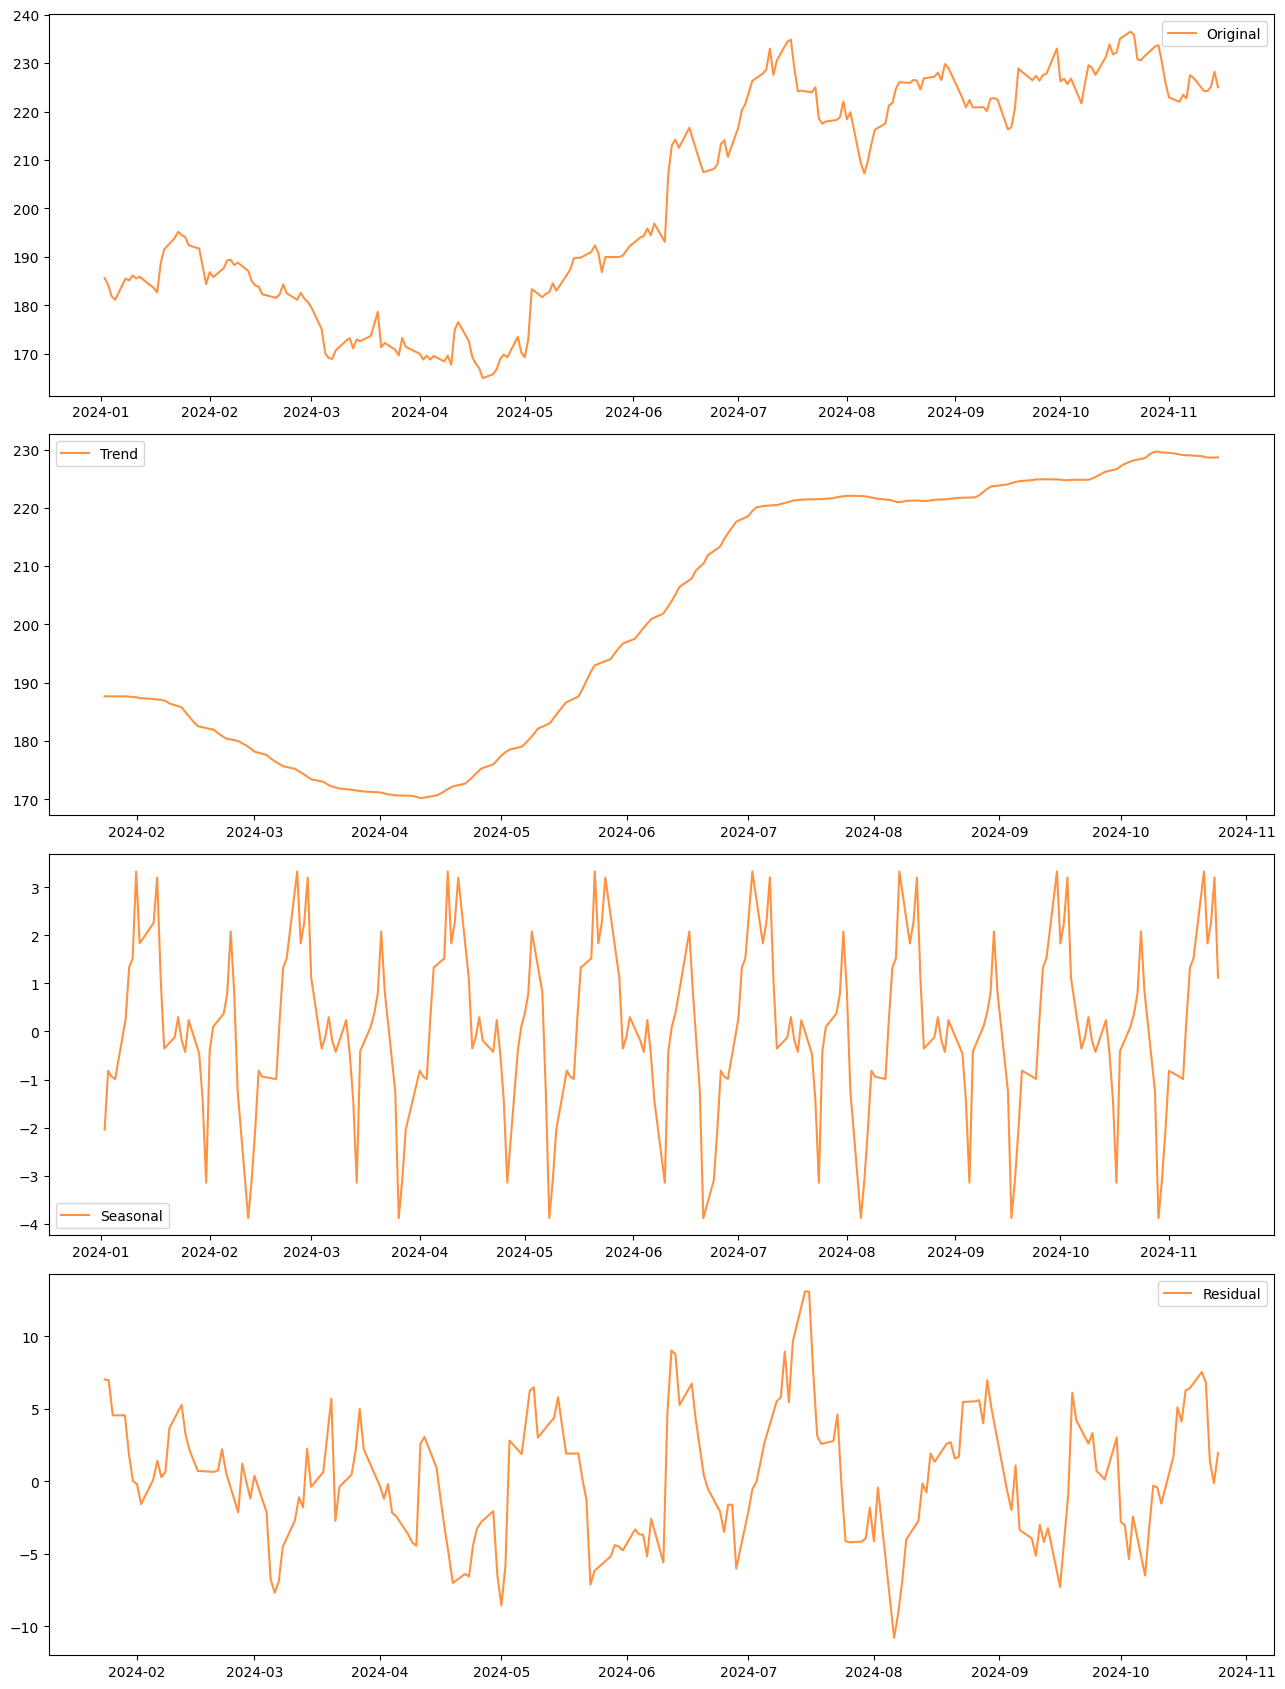

In [109]:
plt.figure(figsize=(13,17))
plt.subplot(411)
plt.plot(apple_stock_data['Close'], label = 'Original', color = '#ff9140')
plt.legend()

plt.subplot(412)
plt.plot(trend_additive, label = 'Trend', color = '#ff9140')
plt.legend()

plt.subplot(413)
plt.plot(seasonal_additive, label = 'Seasonal', color = '#ff9140')
plt.legend()

plt.subplot(414)
plt.plot(residual_additive, label = 'Residual', color = '#ff9140')
plt.legend()

plt.tight_layout()
plt.show()

# STL decomposition

STL (Seasonal-Trend decomposition using Loess) is a versatile and powerful technique for breaking down a time series into three main components:

1. **Seasonal Component**: Repeating patterns or cycles in the data, like daily, monthly, or yearly cycles.
2. **Trend Component**: Long-term movement in the data, showing whether the values are increasing, decreasing, or stable over time.
3. **Residual Component**: The "noise" or "error" component, capturing any variation that is not explained by the seasonal or trend components.

### Key Features of STL Decomposition:
- **Seasonal-Trend Loess (STL)** uses *Loess* (locally estimated scatterplot smoothing) to smooth out data. 
- **Flexible**: STL allows for custom seasonality windows, making it suitable for time series data with non-fixed seasonality.
- **Robust to Noise**: Can handle noise in data, providing a clearer view of trends and seasonality.

### How STL Decomposition Works
STL decomposition applies Loess smoothing to separate out the trend and seasonal components iteratively, and then extracts the residuals.

### Example: Applying STL Decomposition in Python
To illustrate STL decomposition, let's use a sample time series. Here’s how to do it with Python’s `statsmodels` library.

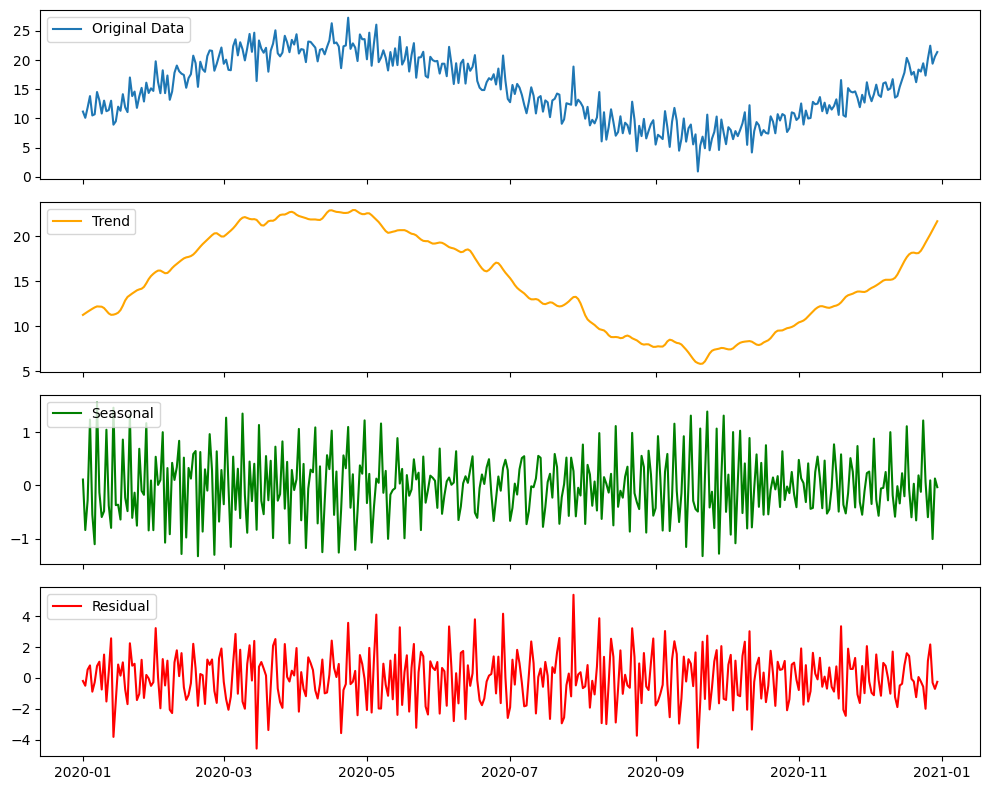

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# Generate a sample time series with a trend, seasonality, and noise
np.random.seed(42)
time = pd.date_range(start='2020-01-01', periods=365, freq='D')
trend = np.linspace(10, 20, 365)  # Linear trend
seasonal = 10 * np.sin(2 * np.pi * time.dayofyear / 365)  # Yearly seasonality
noise = np.random.normal(scale=2, size=365)  # Random noise
data = trend + seasonal + noise

# Create a DataFrame
df = pd.DataFrame({'Date': time, 'Value': data}).set_index('Date')

# Apply STL decomposition
stl = STL(df['Value'], seasonal=13)
result = stl.fit()

# Plot the components
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
ax1.plot(df['Value'], label='Original Data')
ax1.legend(loc='upper left')
ax2.plot(result.trend, label='Trend', color='orange')
ax2.legend(loc='upper left')
ax3.plot(result.seasonal, label='Seasonal', color='green')
ax3.legend(loc='upper left')
ax4.plot(result.resid, label='Residual', color='red')
ax4.legend(loc='upper left')

plt.tight_layout()
plt.show()

### Explanation of the Plot
1. **Original Data**: Shows the entire time series with trend, seasonality, and noise combined.
2. **Trend Component**: Extracts the long-term upward movement.
3. **Seasonal Component**: Shows the repeating pattern over time.
4. **Residual Component**: Shows the remaining noise after removing the trend and seasonality.

### Summary
STL decomposition is useful because it allows for:
- **Analyzing** the behavior of the trend and seasonality independently.
- **Cleaning** the data by removing seasonality or detrending.
- **Modeling** each component separately or combining them into predictive models.

# Classical and STL usage
Choosing between **Classical Decomposition** and **STL Decomposition** depends on the characteristics of the time series and the specific goals of the analysis.

### 1. Classical Decomposition
Classical decomposition splits a time series into **additive** or **multiplicative** components (Trend, Seasonal, and Residual). It works well under certain conditions but is limited in flexibility.

#### When to Use Classical Decomposition:
- **Fixed, Regular Seasonality**: The time series has a stable and known seasonal pattern (e.g., monthly, quarterly) that does not change over time.
- **Simple Patterns**: The time series has clear and consistent seasonality and trend, without significant variation or noise.
- **Quick Analysis or Exploration**: If you need a fast, straightforward decomposition to explore general trends and seasonal components without high accuracy demands.
- **Stationary Seasonality**: If seasonality doesn’t vary in magnitude or frequency over time (e.g., temperature data with a clear annual cycle).

> **Example**: Monthly retail sales data with predictable seasonal peaks (e.g., December holiday shopping).

#### Limitations of Classical Decomposition:
- **Inflexible Seasonality**: Classical decomposition cannot handle time series where seasonal patterns shift over time.
- **Non-Adaptability**: It does not handle complex, non-linear trends well and struggles with irregular or non-fixed seasonality.

### 2. STL Decomposition
STL (Seasonal-Trend decomposition using Loess) is more versatile and flexible, as it doesn’t require the seasonality to be fixed. It handles complex time series better and can deal with irregularities in seasonal patterns.

#### When to Use STL Decomposition:
- **Varying Seasonality**: The seasonality pattern changes over time in magnitude or frequency (e.g., retail sales influenced by changing consumer behavior).
- **Noise in Data**: STL is robust to noise, making it suitable for noisy time series.
- **Non-linear Trends**: STL handles non-linear and non-stationary trends better than classical methods.
- **Customization Needs**: If you need to adjust the seasonality or trend smoothness, STL allows fine-tuning of these parameters.
- **Missing Values**: STL is more tolerant of missing data than classical decomposition, making it more practical for real-world applications.

> **Example**: Hourly website traffic data with changing patterns over months and years or monthly energy consumption with varying seasonal effects.

#### Limitations of STL:
- **Computationally Intensive**: STL requires more computational resources, especially for large datasets, as it iteratively smooths components.
- **Complexity**: The results can be harder to interpret due to the number of tuning parameters.

### Summary
| **Criterion**                | **Classical Decomposition**                | **STL Decomposition**                     |
|------------------------------|--------------------------------------------|-------------------------------------------|
| **Seasonality**              | Fixed and regular                          | Can vary over time                        |
| **Trend**                    | Simple, stationary                         | Complex, non-linear                       |
| **Noise Tolerance**          | Less tolerant                              | More robust to noise                      |
| **Data Requirements**        | Complete data                              | Tolerates missing values                  |
| **Computational Resources**  | Low                                        | Higher (more computationally intensive)   |
| **Customization**            | Limited                                    | Highly customizable                       |

In summary, **Classical Decomposition** is ideal for quick, exploratory analysis of stable time series with fixed seasonality, while **STL Decomposition** excels for complex, noisy time series with flexible seasonal patterns. If the seasonality or trend is expected to change over time or if the series has irregular patterns, STL is generally a better choice.

# Stationarity tests

There're following stationarity statistical tests:
<ol type = "a">
   <li>ADF test</li>
   <li>KPSS test</li>
   <li>KS test/K-S test</li>
</ol>


Let’s go through each of the stationarity tests one by one to understand what they do and how they work.

---

### a. **ADF Test (Augmented Dickey-Fuller Test)**

The **Augmented Dickey-Fuller (ADF) Test** is one of the most popular tests for checking if a time series is **stationary**.

#### What it Does:
The ADF test looks for a **unit root** in the data, which is a characteristic of non-stationary series. If the data has a unit root, it means the time series has a trend, making it non-stationary. 

#### How it Works:
1. **Hypotheses**:
   - **Null Hypothesis (H₀)**: The series has a unit root (it’s non-stationary).
   - **Alternative Hypothesis (H₁)**: The series does not have a unit root (it’s stationary).
   
2. **Test Statistic**:
   - The test gives a test statistic value that is compared to critical values. If the test statistic is less than the critical value (or if the p-value is below a chosen significance level, usually 0.05), you reject the null hypothesis, suggesting that the series is stationary.

3. **Interpretation**:
   - If **p-value < 0.05**: Reject the null hypothesis; the series is likely stationary.
   - If **p-value > 0.05**: Fail to reject the null hypothesis; the series is likely non-stationary.

#### Example Use:
```python
from statsmodels.tsa.stattools import adfuller

# Apply ADF test
result = adfuller(time_series)
print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Series is stationary")
else:
    print("Series is non-stationary")
```

---

### b. **KPSS Test (Kwiatkowski-Phillips-Schmidt-Shin Test)**

The **KPSS Test** is another test for stationarity, but it works differently from the ADF test. Instead of looking for a unit root, it tests if the series is **trend-stationary**.

#### What it Does:
The KPSS test checks if a time series has a **stationary trend** or not. It’s often used to confirm results from the ADF test because the two tests work in opposite ways.

#### How it Works:
1. **Hypotheses**:
   - **Null Hypothesis (H₀)**: The series is stationary (no unit root).
   - **Alternative Hypothesis (H₁)**: The series is non-stationary (has a unit root).
   
2. **Test Statistic**:
   - Similar to the ADF test, KPSS produces a test statistic and a critical value. However, here, if the test statistic is greater than the critical value (or if the p-value is below 0.05), you reject the null hypothesis and conclude that the series is non-stationary.

3. **Interpretation**:
   - If **p-value < 0.05**: Reject the null hypothesis; the series is likely non-stationary.
   - If **p-value > 0.05**: Fail to reject the null hypothesis; the series is likely stationary.

#### Example Use:
```python
from statsmodels.tsa.stattools import kpss

# Apply KPSS test
result = kpss(time_series)
print("KPSS Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Series is non-stationary")
else:
    print("Series is stationary")
```

---

### c. **KS Test (Kolmogorov-Smirnov Test)**

The **Kolmogorov-Smirnov (KS) Test** is a general-purpose test that’s used to check if a sample follows a specific distribution. While it’s not a stationarity test per se, it can sometimes be used in time series analysis to check if the distribution of values has changed over time (e.g., in different periods).

#### What it Does:
The KS test compares the distribution of your time series data to a specific reference distribution (e.g., normal distribution) to see if they’re the same. 

#### How it Works:
1. **Hypotheses**:
   - **Null Hypothesis (H₀)**: The sample data follows the reference distribution.
   - **Alternative Hypothesis (H₁)**: The sample data does not follow the reference distribution.
   
2. **Test Statistic**:
   - The KS test calculates the maximum distance between the cumulative distribution function (CDF) of the sample and the CDF of the reference distribution.
   - If the test statistic is large (or p-value is low), it suggests that the data does not follow the reference distribution.

3. **Interpretation**:
   - If **p-value < 0.05**: Reject the null hypothesis; the data does not follow the reference distribution.
   - If **p-value > 0.05**: Fail to reject the null hypothesis; the data follows the reference distribution.

#### Example Use:
```python
from scipy.stats import kstest

# Apply KS test
result = kstest(time_series, 'norm')  # Compare to normal distribution
print("KS Statistic:", result.statistic)
print("p-value:", result.pvalue)

if result.pvalue < 0.05:
    print("Data does not follow the normal distribution")
else:
    print("Data follows the normal distribution")
```

---

### Summary

- **ADF Test**: Looks for unit roots to identify if a series is non-stationary.
- **KPSS Test**: Tests for trend-stationarity by looking for the presence of a trend.
- **KS Test**: Compares the data’s distribution to a reference distribution (e.g., normal distribution) and isn’t specifically a stationarity test but can be useful for analyzing distributional changes.

Each test gives insights into different aspects of time series stationarity and distribution, helping to decide the right pre-processing steps before modeling.

## Other examples of ADF, KPSS, K-S test

### ADF test example

In [111]:
from statsmodels.tsa.stattools import adfuller

adf_test_val = adfuller(apple_stock_data['Close'])

print("ADF statistic: ", adf_test_val[0])
print("P-value: ", adf_test_val[1])
print("Critical values: ")
for key, val in adf_test_val[4].items():
    print(f"  {key}: {val}")

ADF statistic:  -0.8371164533133034
P-value:  0.8079755864157105
Critical values: 
  1%: -3.4602906385073884
  5%: -2.874708679520702
  10%: -2.573788599127782


### KPSS test example

In [112]:
from statsmodels.tsa.stattools import kpss

kpss_test = kpss(x=apple_stock_data['Close'],regression='ct')

print("KPSS statistics: ", kpss_test[0])
print("KPSS p-value: ", kpss_test[1])
print("Critical value of kpss test: ")
for key, val in kpss_test[3].items():
    print(f"\t{key}: {val}")

KPSS statistics:  0.25435901355956453
KPSS p-value:  0.01
Critical value of kpss test: 
	10%: 0.119
	5%: 0.146
	2.5%: 0.176
	1%: 0.216


### KS Test

#### By me
This method is used with the referenced distribution as input as well.

In [113]:
from statsmodels.stats.diagnostic import kstest_fit

kstest_val = kstest_fit(x = apple_stock_data['Close'], dist='exp')

print("KS test statistic: ", kstest_val[0])
print("KS test p-value: ", kstest_val[1])

KS test statistic:  0.5577506533135101
KS test p-value:  0.0009999999999998899


#### Using scipy stats

##### KS1 sample test

In [114]:
from scipy.stats import ks_1samp, norm

ks1_val = ks_1samp(x=apple_stock_data['Close'], cdf=norm.cdf)
print("KS1 statistic:", ks1_val.statistic[0])
print("P-value:", ks1_val.pvalue[0])

KS1 statistic: 1.0
P-value: 0.0


In [115]:
from scipy.stats import ks_1samp, expon

ks1_val = ks_1samp(x=apple_stock_data['Close'], cdf=expon.cdf)
print("KS1 statistic:", ks1_val.statistic[0])
print("P-value:", ks1_val.pvalue[0])

KS1 statistic: 1.0
P-value: 0.0


##### KS test with generated strict and non-strict stationary series

In [116]:
import numpy as np
from scipy.stats import ks_2samp
from numpy.typing import ArrayLike

np.random.seed(42)
n = 500

strict_stationary_series = np.random.normal(0, 1, n)
non_strict_stationary_series = np.concatenate([
    np.random.normal(0, 2, n // 2),
    np.random.normal(0, 2, n // 2)
])

def ks2_samp(series: ArrayLike):
    """
    Test of stationarity using ks testing technique
    for stationarity
    """

    split = len(series) // 2
    series_first_half = series[:split]
    series_second_half = series[split:]
    kstats, pval = ks_2samp(series_first_half, series_second_half)
    return kstats, pval

strict_ks2_tats, strict_ks2_pval = ks2_samp(strict_stationary_series)
print("Strict stationary ks2 stats:", strict_ks2_tats)
print("Strict stationarity ks2 p value:", strict_ks2_pval)

weak_ks2_stats, weak_pval = ks2_samp(non_strict_stationary_series)
print("Strict stationary ks2 stats:", weak_ks2_stats)
print("Strict stationarity ks2 p value:", weak_pval)

Strict stationary ks2 stats: 0.052
Strict stationarity ks2 p value: 0.8888778031778077
Strict stationary ks2 stats: 0.092
Strict stationarity ks2 p value: 0.24091783209209974


# Converting non-stationary data to stationary

## Differencing
Subtracts the current occurrence of a series' output from its previous output. Can be done up-to nth order, where n could be the order of seasonality date.

## Transforming
Stabilizes the variance of a timeseries.
* Log transformation
* Exponential transformation (sqrt, cubic-root etc.)
* Box-cox (Combination of log and exponential) transformation

## De-trending
### a. Linear de-trending
* Fit a regression line over the trend line.
* Subtract the non-fitted points from the trend line data points, you're done.

### b. Moving average de-trending
* Select a window size, to select the number of elements to make sum of.
* Add the sum of the number, adjacent to the first number; coming in the scope of the window.

## Seasonal adjustment
Removing seasonal component from the series, using `STL`.

---

Below is the code demo of each of them

## Stationarity checks

In [117]:
from statsmodels.tsa.stattools import adfuller
from numpy.typing import ArrayLike

def adf_stationarity_test(series: ArrayLike):
    adf_test_val = adfuller(series)

    print("ADF statistic: ", adf_test_val[0])
    print("P-value: ", adf_test_val[1])
    print("Critical values: ")
    for key, val in adf_test_val[4].items():
        print(f"  {key}: {val}")

In [118]:
from scipy.stats import ks_2samp

def ks2_samp(series: ArrayLike):
    """
    Test of stationarity using ks testing technique
    for stationarity
    """

    split = len(series) // 2
    series_first_half = series[:split]
    series_second_half = series[split:]
    kstats, pval = ks_2samp(series_first_half, series_second_half)
    print("Kstats:", kstats[0])
    print("P-value of ks test:", pval[0])

In [119]:
# Actual demonstration of the stationality check
# Differencing
prices = apple_stock_data['Close']
differenced_price = prices.diff()
differenced_price

Ticker,AAPL
Date,
2024-01-02 00:00:00+00:00,NaN
2024-01-03 00:00:00+00:00,-1.389999
2024-01-04 00:00:00+00:00,-2.339996
2024-01-05 00:00:00+00:00,-0.730011
2024-01-08 00:00:00+00:00,4.380005
...,...
2024-11-11 00:00:00+00:00,-2.730011
2024-11-12 00:00:00+00:00,0.000000
2024-11-13 00:00:00+00:00,0.889999


In [120]:
prices

Ticker,AAPL
Date,
2024-01-02 00:00:00+00:00,185.639999
2024-01-03 00:00:00+00:00,184.250000
2024-01-04 00:00:00+00:00,181.910004
2024-01-05 00:00:00+00:00,181.179993
2024-01-08 00:00:00+00:00,185.559998
...,...
2024-11-11 00:00:00+00:00,224.229996
2024-11-12 00:00:00+00:00,224.229996
2024-11-13 00:00:00+00:00,225.119995


In [121]:
adf_stationarity_test(differenced_price.dropna())

ADF statistic:  -13.954253560092848
P-value:  4.6422468136782184e-26
Critical values: 
  1%: -3.4604283689894815
  5%: -2.874768966942149
  10%: -2.57382076446281


In [122]:
ks2_samp(differenced_price.dropna())

Kstats: 0.15225225225225225
P-value of ks test: 0.12667971769871716


In [123]:
import numpy as np
# log transform
logged_transform = np.log(prices)
logged_transform

Ticker,AAPL
Date,
2024-01-02 00:00:00+00:00,5.223809
2024-01-03 00:00:00+00:00,5.216294
2024-01-04 00:00:00+00:00,5.203512
2024-01-05 00:00:00+00:00,5.199491
2024-01-08 00:00:00+00:00,5.223378
...,...
2024-11-11 00:00:00+00:00,5.412672
2024-11-12 00:00:00+00:00,5.412672
2024-11-13 00:00:00+00:00,5.416634


In [124]:
adf_stationarity_test(logged_transform)

ADF statistic:  -0.8161349857694891
P-value:  0.814336532720312
Critical values: 
  1%: -3.4602906385073884
  5%: -2.874708679520702
  10%: -2.573788599127782


In [125]:
sqrt_transform = np.sqrt(prices)
sqrt_transform

Ticker,AAPL
Date,
2024-01-02 00:00:00+00:00,13.624977
2024-01-03 00:00:00+00:00,13.573872
2024-01-04 00:00:00+00:00,13.487402
2024-01-05 00:00:00+00:00,13.460312
2024-01-08 00:00:00+00:00,13.622041
...,...
2024-11-11 00:00:00+00:00,14.974311
2024-11-12 00:00:00+00:00,14.974311
2024-11-13 00:00:00+00:00,15.003999


In [126]:
adf_stationarity_test(sqrt_transform)

ADF statistic:  -0.8244720224658089
P-value:  0.8118277021085691
Critical values: 
  1%: -3.4602906385073884
  5%: -2.874708679520702
  10%: -2.573788599127782


In [127]:
from scipy.stats import boxcox

boxcox_transform = boxcox(prices['AAPL'].values)
boxcox_transform

(array([609.02461009, 603.21330707, 593.45740417, 590.42085611,
        608.68981445, 606.9328344 , 611.3273599 , 608.8153502 ,
        610.19667419, 600.62510098, 596.66386504, 621.56558186,
        633.90780988, 643.75968532, 649.22811943, 646.3443115 ,
        644.9457885 , 637.54032231, 634.6255027 , 619.08655421,
        603.83982435, 614.13502376, 609.90364473, 617.57500067,
        624.38326324, 624.84613297, 620.26281242, 622.4904964 ,
        615.35111273, 606.51463935, 602.79566404, 601.58495271,
        595.12263325, 592.00110394, 595.16431812, 603.71450972,
        595.99732086, 590.33775705, 596.45558855, 591.41881184,
        588.63382948, 584.1090854 , 565.26171189, 544.83155804,
        540.74869748, 540.25921779, 547.32533948, 555.60084901,
        557.57119909, 548.96196839, 556.6268952 , 555.06744572,
        559.58418241, 569.30100685, 580.00593189, 549.94438674,
        553.6729789 , 547.81624915, 543.15683484, 557.89974681,
        550.3948087 , 544.46384559, 539.

In [129]:
adf_stationarity_test(boxcox_transform[0])

ADF statistic:  -0.8457973771372733
P-value:  0.8052980460317085
Critical values: 
  1%: -3.4602906385073884
  5%: -2.874708679520702
  10%: -2.573788599127782


In [130]:
import numpy as np

# Convert the 'AAPL' column in 'prices' to a Series
prices_series = prices['AAPL']

# Fit a linear trend line
trendline_coeff = np.polyfit(np.arange(len(prices_series)), prices_series, 1)
trendline = np.polyval(trendline_coeff, np.arange(len(prices_series)))

# Calculate the detrended prices
detrended_prices = prices_series - trendline

In [131]:
adf_stationarity_test(detrended_prices)

ADF statistic:  -1.9798960358674622
P-value:  0.29545695276452655
Critical values: 
  1%: -3.4602906385073884
  5%: -2.874708679520702
  10%: -2.573788599127782


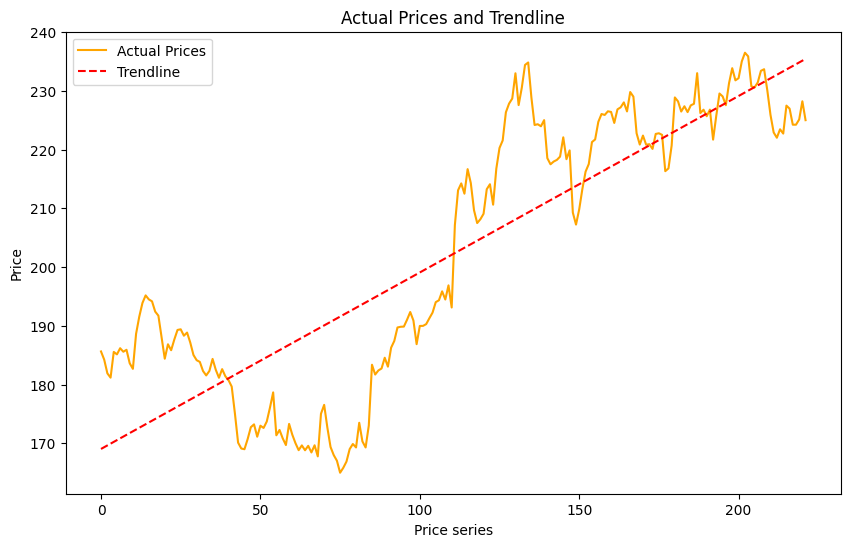

In [132]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(prices_series)), prices_series, label='Actual Prices', color='orange')
plt.plot(np.arange(len(prices_series)), trendline, label='Trendline', color='red', linestyle='--')
plt.xlabel('Price series')
plt.ylabel('Price')
plt.title('Actual Prices and Trendline')
plt.legend()
plt.show()

In [133]:
window_size = 12
prices_ma = prices.rolling(window = window_size).mean()
# prices_ma.dropna(inplace=True)
prices_ma_detrended = prices - prices_ma
# prices_ma_detrended.dropna(inplace=True)
prices_ma_detrended

Ticker,AAPL
Date,
2024-01-02 00:00:00+00:00,NaN
2024-01-03 00:00:00+00:00,NaN
2024-01-04 00:00:00+00:00,NaN
2024-01-05 00:00:00+00:00,NaN
2024-01-08 00:00:00+00:00,NaN
...,...
2024-11-11 00:00:00+00:00,-2.790838
2024-11-12 00:00:00+00:00,-2.192504
2024-11-13 00:00:00+00:00,-0.612504


In [134]:
adf_stationarity_test(prices_ma_detrended.dropna())

ADF statistic:  -4.380919138196966
P-value:  0.0003207829660168435
Critical values: 
  1%: -3.4620315036789666
  5%: -2.8754705024827127
  10%: -2.5741950726860647


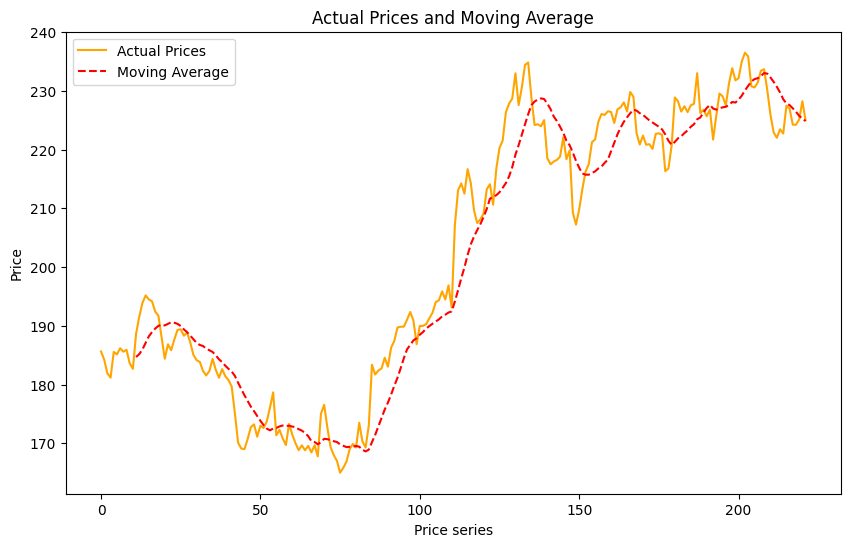

In [135]:
plt.figure(figsize=(10, 6))
plt.plot(np.arange(len(prices_series)), prices_series, label='Actual Prices', color='orange')
plt.plot(np.arange(len(prices_series)), prices_ma, label='Moving Average', color='red', linestyle='--')
plt.xlabel('Price series')
plt.ylabel('Price')
plt.title('Actual Prices and Moving Average')
plt.legend()
plt.show()

In [136]:
from statsmodels.tsa.seasonal import seasonal_decompose

prices_decomposition = seasonal_decompose(x=prices, model='additive', period=28)
deseasoned_prices = prices / prices_decomposition.seasonal
deseasoned_prices.dropna()

,AAPL,2024-01-02 00:00:00+00:00,2024-01-03 00:00:00+00:00,2024-01-04 00:00:00+00:00,2024-01-05 00:00:00+00:00,2024-01-08 00:00:00+00:00,2024-01-09 00:00:00+00:00,2024-01-10 00:00:00+00:00,2024-01-11 00:00:00+00:00,2024-01-12 00:00:00+00:00,...,2024-11-04 00:00:00+00:00,2024-11-05 00:00:00+00:00,2024-11-06 00:00:00+00:00,2024-11-07 00:00:00+00:00,2024-11-08 00:00:00+00:00,2024-11-11 00:00:00+00:00,2024-11-12 00:00:00+00:00,2024-11-13 00:00:00+00:00,2024-11-14 00:00:00+00:00,2024-11-15 00:00:00+00:00
Date,,,,,,,,,,,,,,,,,,,,,


In [137]:
from statsmodels.tsa.seasonal import STL

prices_stl = STL(prices['AAPL'], seasonal=13, period=30)
prices_decomposed = prices_stl.fit()

prices_de_seasoned = prices / prices_decomposed.seasonal
prices_de_seasoned.dropna()

,AAPL,2024-01-02 00:00:00+00:00,2024-01-03 00:00:00+00:00,2024-01-04 00:00:00+00:00,2024-01-05 00:00:00+00:00,2024-01-08 00:00:00+00:00,2024-01-09 00:00:00+00:00,2024-01-10 00:00:00+00:00,2024-01-11 00:00:00+00:00,2024-01-12 00:00:00+00:00,...,2024-11-04 00:00:00+00:00,2024-11-05 00:00:00+00:00,2024-11-06 00:00:00+00:00,2024-11-07 00:00:00+00:00,2024-11-08 00:00:00+00:00,2024-11-11 00:00:00+00:00,2024-11-12 00:00:00+00:00,2024-11-13 00:00:00+00:00,2024-11-14 00:00:00+00:00,2024-11-15 00:00:00+00:00
Date,,,,,,,,,,,,,,,,,,,,,


In [138]:
from statsmodels.tsa.seasonal import seasonal_decompose
import numpy as np

# Ensure `prices` is a single column Series
prices_series = prices['AAPL']

# Check for and handle missing values
prices_series = prices_series.fillna(method='ffill').fillna(method='bfill')

# Perform decomposition with a suitable period
try:
    decomposition = seasonal_decompose(prices_series, model='additive', period=5)  # Adjust period as needed
    deseasoned_prices = prices_series - decomposition.seasonal
    deseasoned_prices = deseasoned_prices.dropna()  # Remove NaNs, if any, after decomposition
except ValueError as e:
    print("Error during decomposition:", e)

# Check if deseasoned data is now stationary with ADF
from statsmodels.tsa.stattools import adfuller
result = adfuller(deseasoned_prices)
print("ADF test statistic:", result[0])
print("p-value:", result[1])

ADF test statistic: -0.8378843731994882
p-value: 0.8077398102983435


In [139]:
first_diff = prices_series.diff().dropna()
second_diff = first_diff.diff().dropna()
adf_result = adfuller(second_diff)
print("ADF test p-value after second differencing:", adf_result[1])

ADF test p-value after second differencing: 3.3172675871544726e-11


In [140]:
3.3172675871544726e-11 < 0.05

True

<Axes: xlabel='Date'>

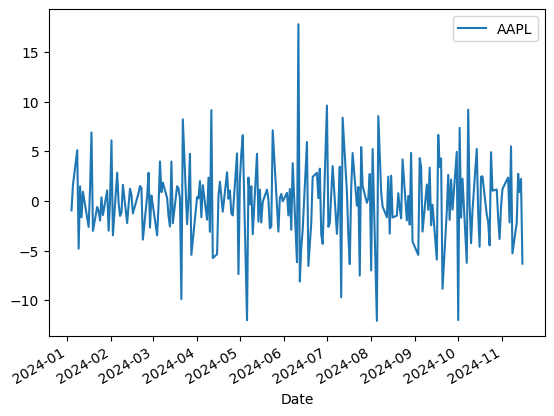

In [141]:
second_diff.to_frame().plot()

In [142]:
# MinMaxScaler
from sklearn.preprocessing import MinMaxScaler, StandardScaler

min_max_scaled = MinMaxScaler().fit_transform(prices)
std_scaled = StandardScaler().fit_transform(prices)

In [143]:
adf_stationarity_test(min_max_scaled)

ADF statistic:  -0.8371164533133029
P-value:  0.8079755864157108
Critical values: 
  1%: -3.4602906385073884
  5%: -2.874708679520702
  10%: -2.573788599127782


In [144]:
adf_stationarity_test(std_scaled)

ADF statistic:  -0.8371164533133028
P-value:  0.8079755864157108
Critical values: 
  1%: -3.4602906385073884
  5%: -2.874708679520702
  10%: -2.573788599127782


# White noise and random walk

***What is white noise?***

A series with no seasonality, trend. Statistically speaking, it has:
  - Constant mean
  - Constant variance
  - No autocorrelation

***What is random walk?***

A random walk in a series is the sum of the previous value(s) to reach the latest or current value, it has a cumulative frequency pattern.

It's generally seen in stock prices. It has following properties:
 - It's predictable, since `y_t_current = y_t_current-1 + error_t_current`. Here `error_t_current` is white noise.
 - It has first difference as a stationary series.
 - It has a varying mean & variance over time.
 - After making the random walk series a stationary one, it is been prepared to be used for training the forecasting model.

## Simulating and testing white noise and random walk

In [145]:
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox
from arch.unitroot import VarianceRatio
import numpy as np

np.random.seed(0)
n = 1000

white_noise = np.random.normal(0,1,n)

random_noise = np.random.normal(0,1,n)
random_walk = np.cumsum(random_noise)

"""
    a. The Variance Ratio Test is specifically designed to detect random walk behavior.
    b. It compares the variance of returns over multiple periods to the variance of returns over single periods.
    c. For a random walk, variances scale linearly with time, so the variance ratio should equal 1. Significant deviations
    from 1 suggest non-random walk behavior.
"""
lj_df = acorr_ljungbox(white_noise, lags=[10])
vr_ratio = VarianceRatio(random_walk)

print("Ljung box test:", lj_df)
print(f"Variance ratio statistics:{vr_ratio.stat}")
print(f"Variance ratio p-value:{vr_ratio.pvalue}")

Ljung box test:       lb_stat  lb_pvalue
10  14.025574   0.171828
Variance ratio statistics:-1.1593266582917727
Variance ratio p-value:0.2463230593870811


Based on the results, let’s break down the interpretation of each test:

### 1. **Ljung-Box Test (for White Noise in `white_noise`)**
   - **Ljung-Box Test Output**: 
     - **Statistic (`lb_stat`)**: 14.025574
     - **P-value (`lb_pvalue`)**: 0.171828
   - **Interpretation**:
     - The p-value is greater than 0.05 (significance level), so we fail to reject the null hypothesis that the series has no autocorrelation.
     - This suggests that `white_noise` is consistent with white noise, as it does not show significant autocorrelation.

### 2. **Variance Ratio Test (for Random Walk in `random_walk`)**
   - **Variance Ratio Test Output**:
     - **Statistic**: -1.1593266582917727
     - **P-value**: 0.2463230593870811
   - **Interpretation**:
     - The p-value here is also greater than 0.05, indicating that we fail to reject the null hypothesis that `random_walk` is indeed a random walk.
     - The negative statistic is typical in variance ratio tests, especially when the series is very close to a random walk, as we expect a variance ratio around 1.

### Overall Summary
- **White Noise Series (`white_noise`)**: The Ljung-Box test results suggest `white_noise` is uncorrelated (consistent with white noise).
- **Random Walk Series (`random_walk`)**: The Variance Ratio test results suggest `random_walk` behaves like a random walk. 

The test's outputs support the series' intended behaviors: the `white_noise` appears uncorrelated (consistent with white noise), and `random_walk` behaves in a way consistent with a random walk.

## White noise checking for `second_diff`

### ACF, PACF plots

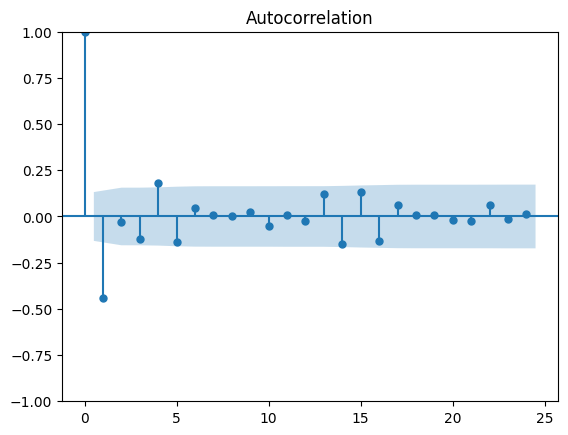

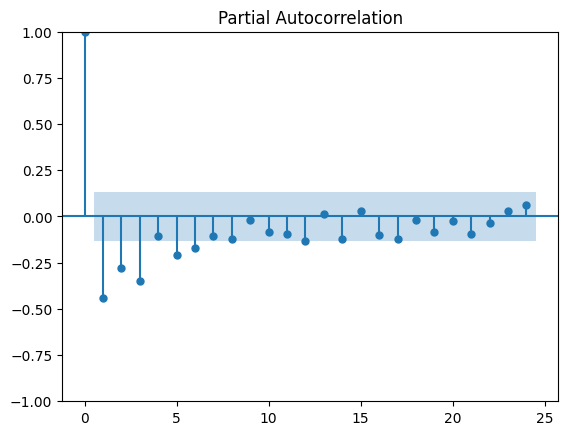

In [146]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(second_diff)
plot_pacf(second_diff)
plt.show()

The partial autocorrelation plot for `second_diff` shows that it has high correlation of 1 with lag 0, and the rest of the plots having negative correlation, the 25th lag has correlation just above 0.00, while, the ACF plot show some correlation with correlation of 1 with lag 0 and other lags have some correlations, with some near 0.00; and lag 1,3,5,10,12,13,20,21,23 have low correlation than 0.00, in negative.

### L-jung-box test

In [147]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(second_diff, lags=[25], return_df=True)
lb_test

,lb_stat,lb_pvalue
25,82.468914,4.658114e-08


The Ljung-Box test results for `second_diff` show:

- **Test Statistic (`lb_stat`)**: 82.57
- **P-value (`lb_pvalue`)**: 4.478297e-08, which is very close to zero.

### Interpretation:

1. **Low P-value**: The extremely low p-value (< 0.05) suggests that the null hypothesis of white noise is rejected. This implies that there is some significant autocorrelation remaining in the differenced series.
  
2. **Implication**: Since the data still shows some autocorrelation, it’s not purely random and may retain some structure or patterns. In practice, this often suggests that there could be further adjustments to make if you’re aiming for a white noise result, such as additional differencing or considering an ARIMA model to model the remaining structure.

In summary, the second differenced data is not behaving as white noise due to this statistically significant result.

### Decomposition of `second_diff`

<Figure size 1000x700 with 0 Axes>

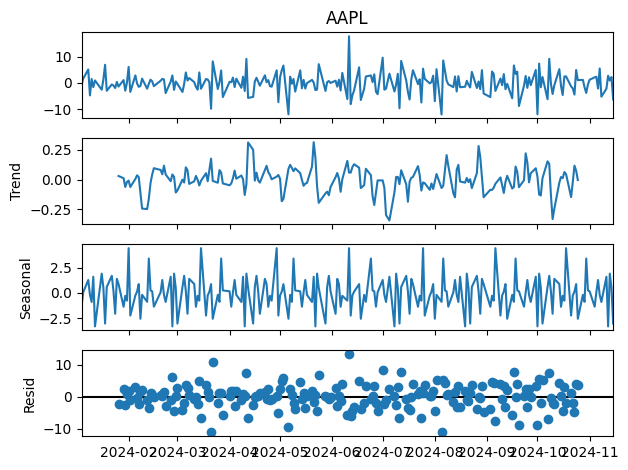

In [148]:
second_diff_decomposed = seasonal_decompose(x=second_diff, period=30)
plt.figure(figsize=(10,7))
second_diff_decomposed.plot()
plt.show()

# Single-variate models

## Simulating workable data

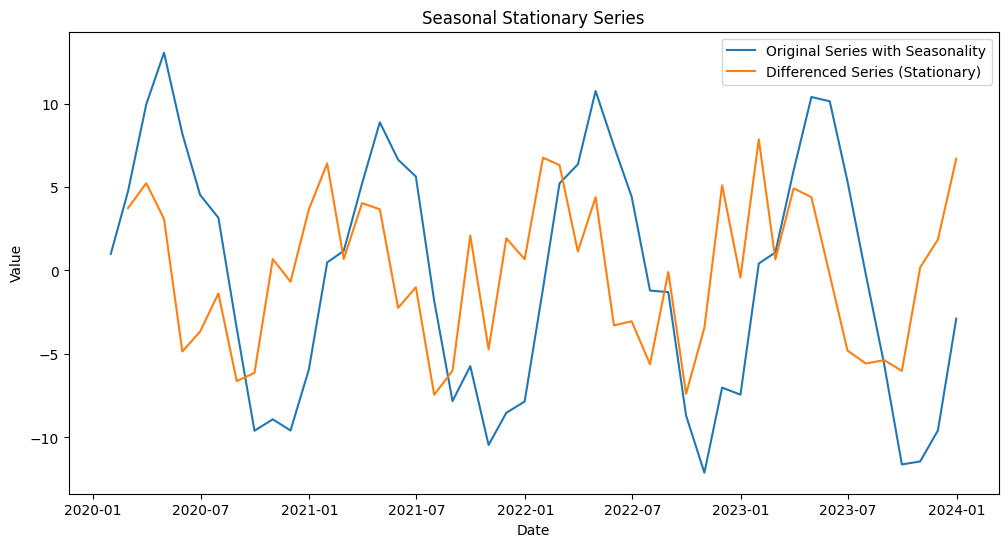

,Value,Differenced_Value
Date,,
2020-01-31,0.993428,NaN
2020-02-29,4.723471,3.730043
2020-03-31,9.955631,5.232160
2020-04-30,13.046060,3.090429
2020-05-31,8.191947,-4.854112
2020-06-30,4.531726,-3.660221
2020-07-31,3.158426,-1.373300
2020-08-31,-3.465131,-6.623556
2020-09-30,-9.599203,-6.134072


In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set a time range from 2020 to 2023 with monthly frequency
date_range = pd.date_range(start='2020-01-01', end='2023-12-31', freq='M')

# Generate a seasonal component with a yearly period
seasonal_period = 12  # 12 months for yearly seasonality
seasonal_component = 10 * np.sin(2 * np.pi * np.arange(len(date_range)) / seasonal_period)

# Generate stationary random noise
np.random.seed(42)  # for reproducibility
stationary_noise = np.random.normal(loc=0, scale=2, size=len(date_range))

# Combine seasonality and noise to form the initial time series
combined_series = seasonal_component + stationary_noise

# Convert to a DataFrame
seasonal_stationary_df = pd.DataFrame({
    'Date': date_range,
    'Value': combined_series
}).set_index('Date')

# Differencing to make the series stationary if needed
seasonal_stationary_df['Differenced_Value'] = seasonal_stationary_df['Value'].diff().dropna()

# Plot the series to visualize
plt.figure(figsize=(12, 6))
plt.plot(seasonal_stationary_df['Value'], label='Original Series with Seasonality')
plt.plot(seasonal_stationary_df['Differenced_Value'], label='Differenced Series (Stationary)')
plt.legend()
plt.title('Seasonal Stationary Series')
plt.xlabel('Date')
plt.ylabel('Value')
plt.show()

seasonal_stationary_df

<Figure size 1000x600 with 0 Axes>

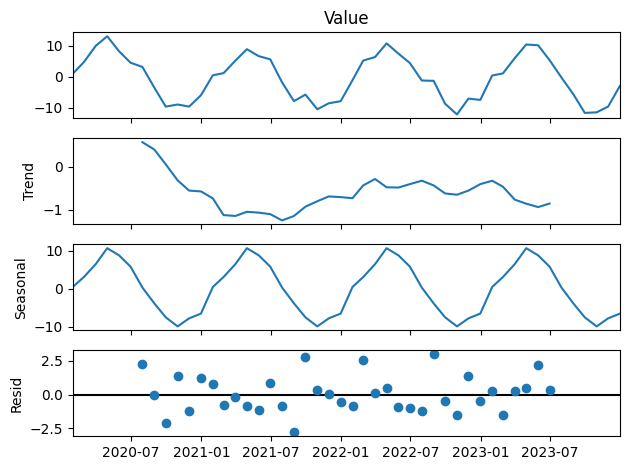

In [150]:
stationary_df_decompose = seasonal_decompose(x=seasonal_stationary_df['Value'])
plt.figure(figsize=(10,6))
stationary_df_decompose.plot()
plt.show()

In [151]:
adf_stationarity_test(seasonal_stationary_df['Value'])

ADF statistic:  -4.928133979197948
P-value:  3.0733582046070065e-05
Critical values: 
  1%: -3.6055648906249997
  5%: -2.937069375
  10%: -2.606985625


In [152]:
seasonal_1st_diff = seasonal_stationary_df['Value'].diff().dropna()
adf_stationarity_test(seasonal_1st_diff)

ADF statistic:  -4.7331439961142285
P-value:  7.288121853763888e-05
Critical values: 
  1%: -3.6209175221605827
  5%: -2.9435394610388332
  10%: -2.6104002410518627


In [153]:
seasonal_stat_2nd_diff = seasonal_1st_diff.diff().dropna()
adf_stationarity_test(seasonal_stat_2nd_diff)

ADF statistic:  -6.792894768471264
P-value:  2.3401544217592943e-09
Critical values: 
  1%: -3.626651907578875
  5%: -2.9459512825788754
  10%: -2.6116707716049383


ADF Statistic: -0.8154520986845555
p-value: 0.8145409395606917


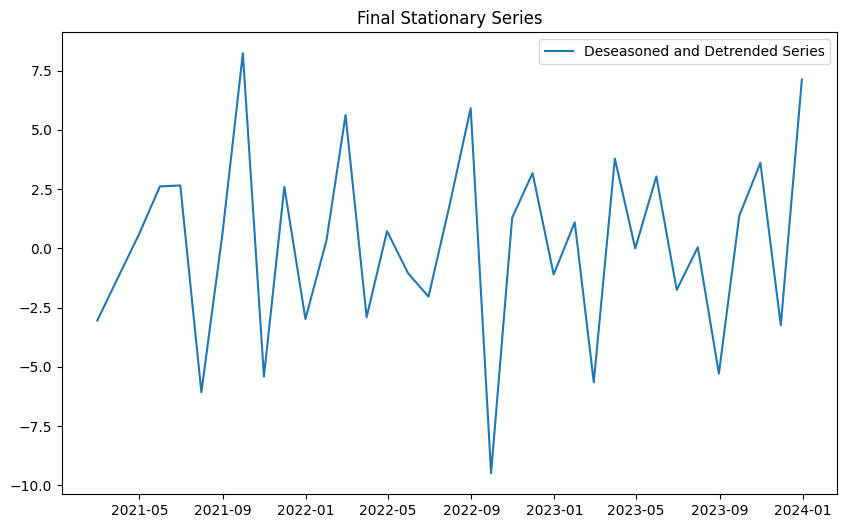

In [154]:
# First, apply first-order differencing to remove the trend
trend_diff = seasonal_stationary_df['Value'].diff().dropna()

# Apply seasonal differencing (assuming yearly seasonality, period=12)
seasonal_diff = trend_diff.diff(periods=12).dropna()

# Check for stationarity with ADF test
from statsmodels.tsa.stattools import adfuller
adf_test = adfuller(seasonal_diff)
print(f"ADF Statistic: {adf_test[0]}")
print(f"p-value: {adf_test[1]}")

# Plot the final transformed series
plt.figure(figsize=(10, 6))
plt.plot(seasonal_diff, label='Deseasoned and Detrended Series')
plt.legend()
plt.title('Final Stationary Series')
plt.show()

### Creating my own `stationary_ts_df`

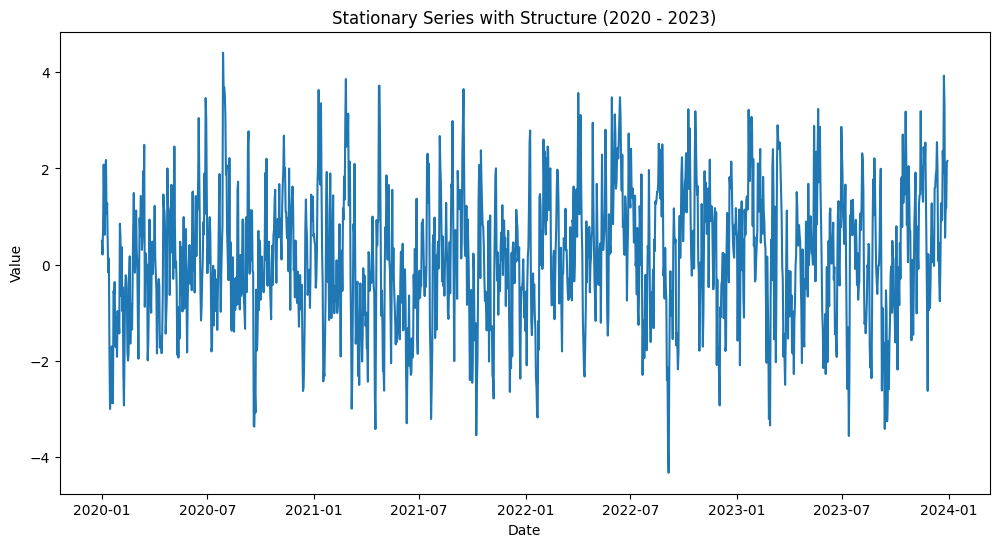

,Value
Date,
2020-01-01,0.496714
2020-01-02,0.209436
2020-01-03,0.794293
2020-01-04,2.079035
2020-01-05,1.221171
...,...
2023-12-26,0.560641
2023-12-27,1.145790
2023-12-28,1.183212


In [155]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima_process import ArmaProcess

# Parameters for a stationary AR(1) process
np.random.seed(42)
ar = np.array([1, -0.7])  # AR coefficient (ensures stationarity with |0.7| < 1)
ma = np.array([1])        # MA coefficient (no moving average part)

# Generate a stationary, non-white-noise time series
arma_process = ArmaProcess(ar, ma)
n_samples = 1460  # 4 years worth of daily data

stationary_series = arma_process.generate_sample(nsample=n_samples)

# Create a DataFrame with this series
dates = pd.date_range(start='2020-01-01', periods=n_samples, freq='D')
stationary_ts_df = pd.DataFrame({'Date': dates, 'Value': stationary_series})
stationary_ts_df.set_index('Date', inplace=True)

# Plot the series
plt.figure(figsize=(12, 6))
plt.plot(stationary_ts_df['Value'])
plt.title("Stationary Series with Structure (2020 - 2023)")
plt.xlabel("Date")
plt.ylabel("Value")
plt.show()

# Display the first few values
stationary_ts_df

### Finding lags

<Figure size 1000x600 with 0 Axes>

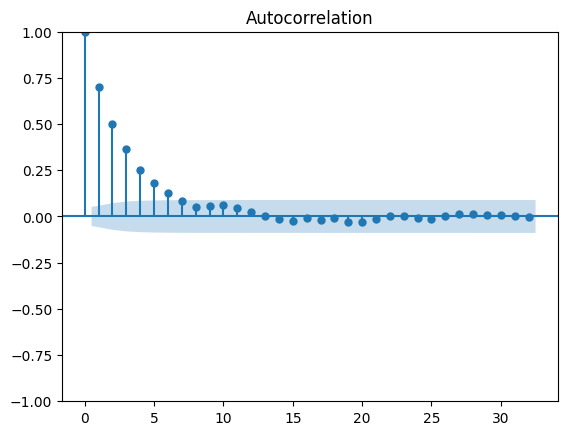

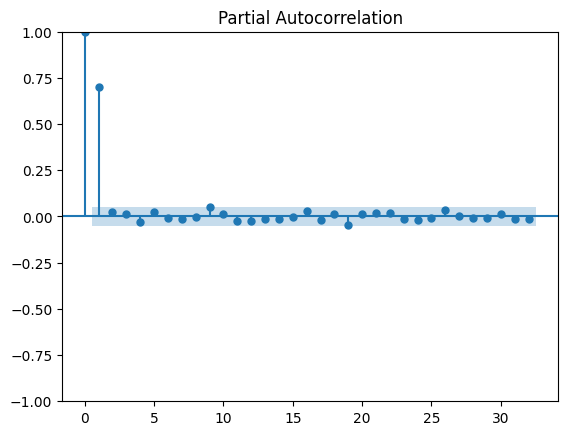

In [156]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plot_acf(stationary_ts_df)
plot_pacf(stationary_ts_df)
plt.show()

### White noise check

In [157]:
from statsmodels.stats.diagnostic import acorr_ljungbox
acorr_ljungbox(x=stationary_ts_df, lags=[30])

,lb_stat,lb_pvalue
30,1477.250326,2.786094e-292


In [158]:
2.786094e-292 < 0.05

True

*Conclusion*: The `stationary_ts_df` is not a white noise

### Random walk test

In [159]:
from arch.unitroot import VarianceRatio

stat_vr = VarianceRatio(stationary_ts_df)

print("The variance ration statistic:", stat_vr.stat)
print("The variance ratio p-val:", stat_vr.pvalue)

The variance ration statistic: -6.186570376893552
The variance ratio p-val: 6.148723752374963e-10


*Conclusion*: Since pvalue is 6.148723752374963e-10, less than 0.05, so it's not a random walk.

### Seasonal decompose of `stationary_ts_df`

<Figure size 1000x500 with 0 Axes>

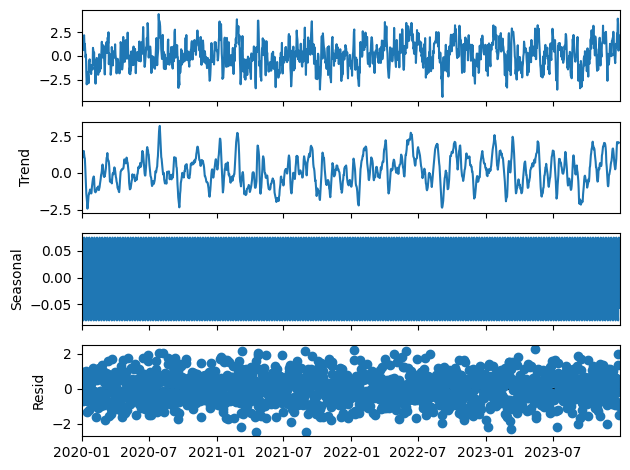

In [160]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
seasonal_decompose(stationary_ts_df).plot()
plt.show()

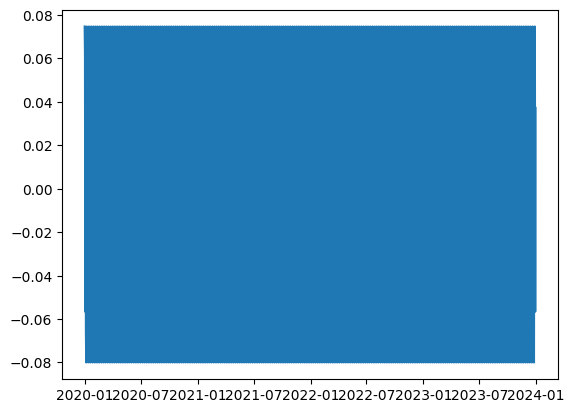

In [161]:
seasonal_wave = seasonal_decompose(stationary_ts_df).seasonal

plt.plot(seasonal_wave)

<Figure size 1000x500 with 0 Axes>

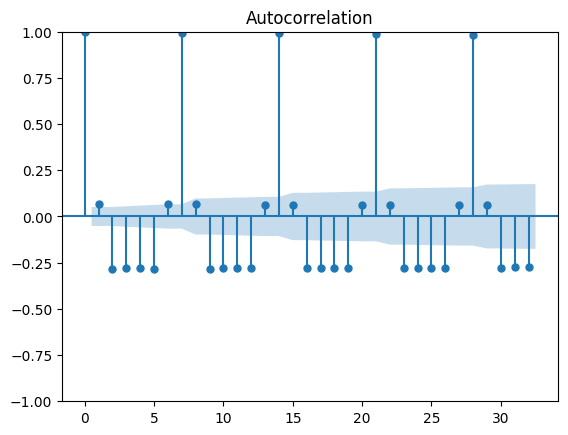

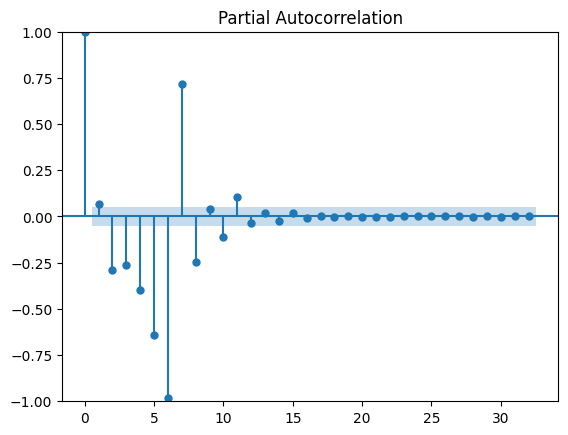

In [162]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plot_acf(seasonal_wave)
plot_pacf(seasonal_wave)
plt.show()

## AR(AutoRegression) Model

### Train test split

In [163]:
from pandas import to_datetime

split_date = to_datetime('2023-01-01')
train_ts = stationary_ts_df.loc[stationary_ts_df.index <= split_date]
test_ts = stationary_ts_df.loc[stationary_ts_df.index > split_date]

In [164]:
train_ts

,Value
Date,
2020-01-01,0.496714
2020-01-02,0.209436
2020-01-03,0.794293
2020-01-04,2.079035
2020-01-05,1.221171
...,...
2022-12-28,0.829129
2022-12-29,0.632336
2022-12-30,1.175275


In [165]:
test_ts

,Value
Date,
2023-01-02,-1.579588
2023-01-03,-0.189384
2023-01-04,0.213920
2023-01-05,1.147754
2023-01-06,-2.092828
...,...
2023-12-26,0.560641
2023-12-27,1.145790
2023-12-28,1.183212


### Modeling

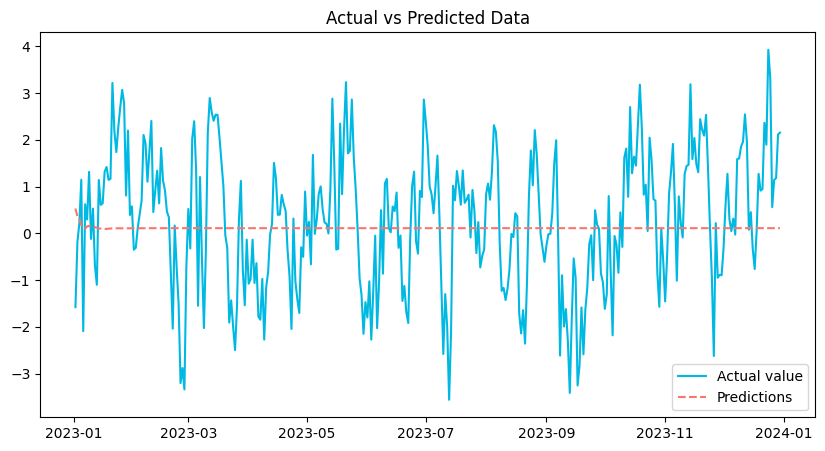

(1.449905768933508, 0.14705130933002047, 0.11411153410159539)

In [166]:
import matplotlib.pyplot as plt
from numpy import sqrt
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.ar_model import AutoReg
from warnings import filterwarnings

filterwarnings('ignore')

model = AutoReg(endog=train_ts['Value'], lags=15).fit()
predictions = model.predict(start = len(train_ts), end=len(train_ts)+len(test_ts)-1, dynamic=False)

rmse = sqrt(mean_squared_error(test_ts, predictions))

plt.figure(figsize=(10,5))
plt.plot(test_ts.index, test_ts['Value'], color='#00B9E3', linestyle='-', label='Actual value')
plt.plot(test_ts.index, predictions.values, color='#F8766D', linestyle='--', label='Predictions')
plt.title('Actual vs Predicted Data')
plt.legend()
plt.show()

rmse, stationary_ts_df['Value'].mean(), predictions.mean()

## MA model

### ARIMA

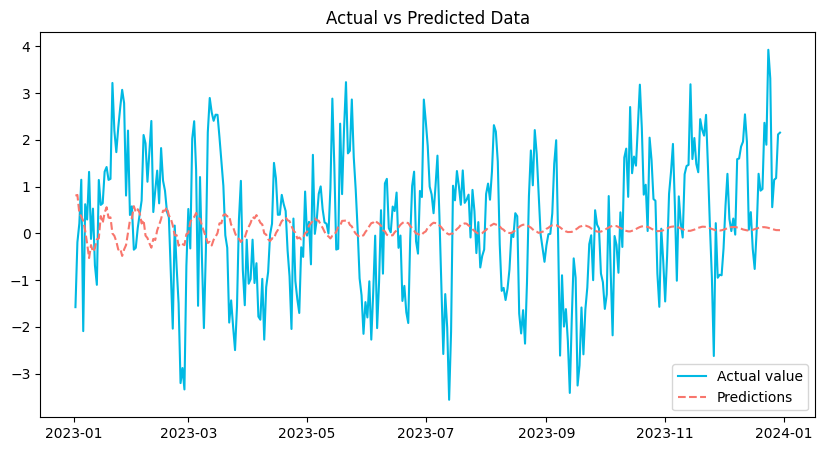

(1.4653940206330727, 0.14705130933002047, 0.0992910378759438)

In [167]:
import matplotlib.pyplot as plt
from numpy import sqrt
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train_ts, order = (22,0,40)).fit()
predictions = model.predict(start = len(train_ts), end=len(train_ts)+len(test_ts)-1, dynamic=False)

rmse = sqrt(mean_squared_error(test_ts, predictions))

plt.figure(figsize=(10,5))
plt.plot(test_ts.index, test_ts['Value'], color='#00B9E3', linestyle='-', label='Actual value')
plt.plot(test_ts.index, predictions.values, color='#F8766D', linestyle='--', label='Predictions')
plt.title('Actual vs Predicted Data')
plt.legend()
plt.show()

rmse, stationary_ts_df['Value'].mean(), predictions.mean()

### SARIMA

In [168]:
seasonality_df = seasonal_wave.to_frame()
seasonality_df

,seasonal
Date,
2020-01-01,0.074715
2020-01-02,0.062447
2020-01-03,-0.056610
2020-01-04,0.037239
2020-01-05,-0.065380
...,...
2023-12-26,0.027600
2023-12-27,0.074715
2023-12-28,0.062447


In [169]:
seasonality_df.diff(160).dropna()

,seasonal
Date,
2020-06-09,-0.047115
2020-06-10,0.012268
2020-06-11,0.119056
2020-06-12,-0.093848
2020-06-13,0.102618
...,...
2023-12-26,-0.047115
2023-12-27,0.012268
2023-12-28,0.119056


In [170]:
adf_stationarity_test(seasonality_df.diff(+3).dropna())

ADF statistic:  -1.0707193208027298e+16
P-value:  0.0
Critical values: 
  1%: -3.4348709954268384
  5%: -2.863536715724964
  10%: -2.567833035595811


RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =            7     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.87142D+00    |proj g|=  9.06170D-01


 This problem is unconstrained.



At iterate    5    f=  1.45420D+00    |proj g|=  1.55335D-01

At iterate   10    f=  1.40688D+00    |proj g|=  2.01266D-02

At iterate   15    f=  1.40373D+00    |proj g|=  6.62864D-03

At iterate   20    f=  1.40350D+00    |proj g|=  5.74228D-04

At iterate   25    f=  1.40338D+00    |proj g|=  7.06602D-03

At iterate   30    f=  1.40278D+00    |proj g|=  2.58021D-03

At iterate   35    f=  1.40272D+00    |proj g|=  3.86170D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
    7     37     47      1     0     0   1.086D-05   1.403D+00
  F =   1.4027211141792926     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH   

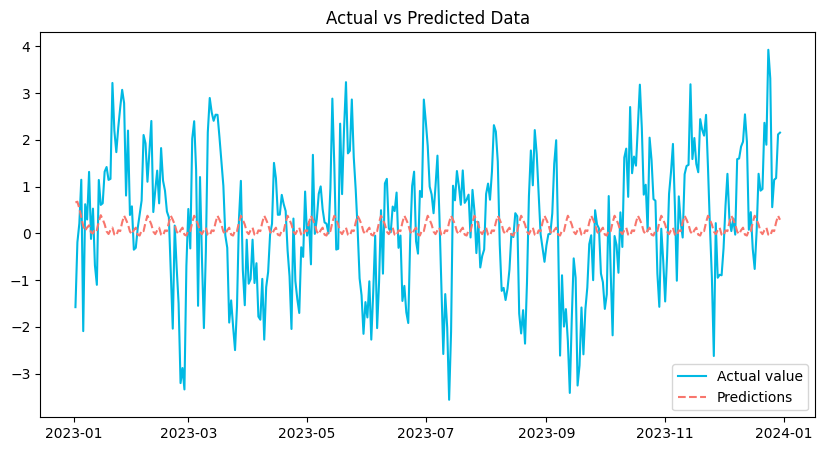

(1.4586892847129778, 0.14705130933002047, 0.1175958287887247)

In [171]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
from numpy import sqrt
from sklearn.metrics import mean_squared_error

p,d,q = 2,0,2
P,D,Q = 1,1,1
s = 12

model = SARIMAX(train_ts, order = (p,d,q), seasonal_order = (P,D,Q,s)).fit()
predictions = model.predict(start = len(train_ts), end=len(train_ts)+len(test_ts)-1, dynamic=False)

rmse = sqrt(mean_squared_error(test_ts, predictions))

plt.figure(figsize=(10,5))
plt.plot(test_ts.index, test_ts['Value'], color='#00B9E3', linestyle='-', label='Actual value')
plt.plot(test_ts.index, predictions.values, color='#F8766D', linestyle='--', label='Predictions')
plt.title('Actual vs Predicted Data')
plt.legend()
plt.show()

rmse, stationary_ts_df['Value'].mean(), predictions.mean()

In [172]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                Value   No. Observations:                 1097
Model:             SARIMAX(2, 0, 2)x(1, 1, [1], 12)   Log Likelihood               -1538.785
Date:                              Sat, 16 Nov 2024   AIC                           3091.570
Time:                                      21:35:00   BIC                           3126.495
Sample:                                  01-01-2020   HQIC                          3104.792
                                       - 01-01-2023                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1096      0.214     -0.513      0.608      -0.528       0.309
ar.L2          0.5960      0.143      4.157      0.000       0.315       0.877
ma.L1          0.7981      0.217      3.674      0.000       0.372       1.224
ma.L2         -0.0532      0.049     -1.091      0.275      -0.149       0.042
ar.S.L12       0.0246      0.033      0.743      0.458      -0.040       0.090
ma.S.L12      -0.9991      0.280     -3.573      0.000      -1.547      -0.451
sigma2         0.9506      0.264      3.602      0.000       0.433       1.468
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.92
Prob(Q):                              0.96   Prob(JB):                         0.63
Heteroskedasticity (H):               1.07   Skew:                             0.07
Prob(H) (two-sided):                  0.54   Kurtosis:                         3.02
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

# Multi-variate models

## Getting stock data

In [173]:
from yfinance import download

apple_stock_23 = download('AAPL', start='2023-01-01')
# tesla_stock_23 = download('TSLA', start='2023-01-01')

[*********************100%***********************]  1 of 1 completed


In [174]:
apple_stock_23

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2023-01-03 00:00:00+00:00,123.768456,125.070000,130.899994,124.169998,130.279999,112117500
2023-01-04 00:00:00+00:00,125.045036,126.360001,128.660004,125.080002,126.889999,89113600
2023-01-05 00:00:00+00:00,123.718979,125.019997,127.769997,124.760002,127.129997,80962700
2023-01-06 00:00:00+00:00,128.271088,129.619995,130.289993,124.889999,126.010002,87754700
2023-01-09 00:00:00+00:00,128.795563,130.149994,133.410004,129.889999,130.470001,70790800
...,...,...,...,...,...,...
2024-11-11 00:00:00+00:00,224.229996,224.229996,225.699997,221.500000,225.000000,42005600
2024-11-12 00:00:00+00:00,224.229996,224.229996,225.589996,223.360001,224.550003,40398300


## Making multi-variate model

### Data pre-processing

In [175]:
from statsmodels.tsa.stattools import grangercausalitytests
from pandas import DataFrame

def granger_causality_matrix(data, maxlag):
    variables = data.columns
    granger_matrix = DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)

    for col in variables:
        for row in variables:
            if row != col:
                test_result = grangercausalitytests(data[[row, col]], maxlag=maxlag, verbose=False)
                # Store p-value for the smallest lag where causality exists
                p_values = [round(test_result[i+1][0]['ssr_ftest'][1], 4) for i in range(maxlag)]
                granger_matrix.loc[row, col] = np.min(p_values)
            else:
                granger_matrix.loc[row, col] = np.nan  # Causality with itself is not relevant

    return granger_matrix

In [176]:
granger_causality_matrix(data=apple_stock_23, maxlag=5)

,Price,Adj Close,Close,High,Low,Open,Volume
,Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Price,Ticker,,,,,,
Adj Close,AAPL,NaN,0.0478,0.3799,0.0384,0.0243,0.8631
Close,AAPL,0.0491,NaN,0.2896,0.1100,0.0413,0.8650
High,AAPL,0.0000,0.0000,NaN,0.0000,0.0378,0.0475
Low,AAPL,0.0000,0.0000,0.0000,NaN,0.0036,0.2157
Open,AAPL,0.0000,0.0000,0.0000,0.0000,NaN,0.5181
Volume,AAPL,0.0092,0.0089,0.0189,0.0123,0.0137,NaN


In [177]:
adf_stationarity_test(apple_stock_23['Volume'])

ADF statistic:  -14.557535515658657
P-value:  4.8537442959970085e-27
Critical values: 
  1%: -3.444310291143469
  5%: -2.867695986993458
  10%: -2.5700489042602586


In [178]:
adf_stationarity_test(apple_stock_23['Open'])

ADF statistic:  -1.7180834214565097
P-value:  0.42182026189018457
Critical values: 
  1%: -3.444310291143469
  5%: -2.867695986993458
  10%: -2.5700489042602586


## Train test split

In [179]:
# from pandas import to_datetime
split_date = '2024-01-23'
train_apple_23 = apple_stock_23[['Open', 'Volume', 'Close']].loc[apple_stock_23.index <= split_date]
test_apple_23 = apple_stock_23[['Open', 'Volume', 'Close']].loc[apple_stock_23.index > split_date]

In [180]:
train_apple_23

Price,Open,Volume,Close
Ticker,AAPL,AAPL,AAPL
Date,,,
2023-01-03 00:00:00+00:00,130.279999,112117500,125.070000
2023-01-04 00:00:00+00:00,126.889999,89113600,126.360001
2023-01-05 00:00:00+00:00,127.129997,80962700,125.019997
2023-01-06 00:00:00+00:00,126.010002,87754700,129.619995
2023-01-09 00:00:00+00:00,130.470001,70790800,130.149994
...,...,...,...
2024-01-17 00:00:00+00:00,181.270004,47317400,182.679993
2024-01-18 00:00:00+00:00,186.089996,78005800,188.630005


In [181]:
test_apple_23

Price,Open,Volume,Close
Ticker,AAPL,AAPL,AAPL
Date,,,
2024-01-24 00:00:00+00:00,195.419998,53631300,194.500000
2024-01-25 00:00:00+00:00,195.220001,54822100,194.169998
2024-01-26 00:00:00+00:00,194.270004,44594000,192.419998
2024-01-29 00:00:00+00:00,192.009995,47145600,191.729996
2024-01-30 00:00:00+00:00,190.940002,55859400,188.039993
...,...,...,...
2024-11-11 00:00:00+00:00,225.000000,42005600,224.229996
2024-11-12 00:00:00+00:00,224.550003,40398300,224.229996


## VAR & VARMAX

In [182]:
from statsmodels.tsa.api import VAR
from numpy import sort

model = VAR(train_apple_23)
model.select_order(maxlags=10).summary()
model_fitted = model.fit(maxlags=6)
forecast_steps = len(test_apple_23)
predictions = model_fitted.forecast(y=test_apple_23.values, steps=forecast_steps)
predictions = sort(predictions, axis=0)
# test_apple_23['close_prediction']
predictions_df = DataFrame(data=predictions, columns=test_apple_23.columns, index = test_apple_23.index)
predictions_df

Price,Open,Volume,Close
Ticker,AAPL,AAPL,AAPL
Date,,,
2024-01-24 00:00:00+00:00,186.369214,4.406997e+07,186.423969
2024-01-25 00:00:00+00:00,186.379866,4.430848e+07,186.434369
2024-01-26 00:00:00+00:00,186.390747,4.431320e+07,186.444990
2024-01-29 00:00:00+00:00,186.401860,4.464147e+07,186.455839
2024-01-30 00:00:00+00:00,186.413211,4.467831e+07,186.466920
...,...,...,...
2024-11-11 00:00:00+00:00,221.382679,5.494585e+07,220.789498
2024-11-12 00:00:00+00:00,221.574396,5.494927e+07,221.162458


In [183]:
predictions_df.columns = ['Open', 'Volume', 'Close']
predictions_df

,Open,Volume,Close
Date,,,
2024-01-24 00:00:00+00:00,186.369214,4.406997e+07,186.423969
2024-01-25 00:00:00+00:00,186.379866,4.430848e+07,186.434369
2024-01-26 00:00:00+00:00,186.390747,4.431320e+07,186.444990
2024-01-29 00:00:00+00:00,186.401860,4.464147e+07,186.455839
2024-01-30 00:00:00+00:00,186.413211,4.467831e+07,186.466920
...,...,...,...
2024-11-11 00:00:00+00:00,221.382679,5.494585e+07,220.789498
2024-11-12 00:00:00+00:00,221.574396,5.494927e+07,221.162458
2024-11-13 00:00:00+00:00,223.276448,5.495261e+07,221.950248


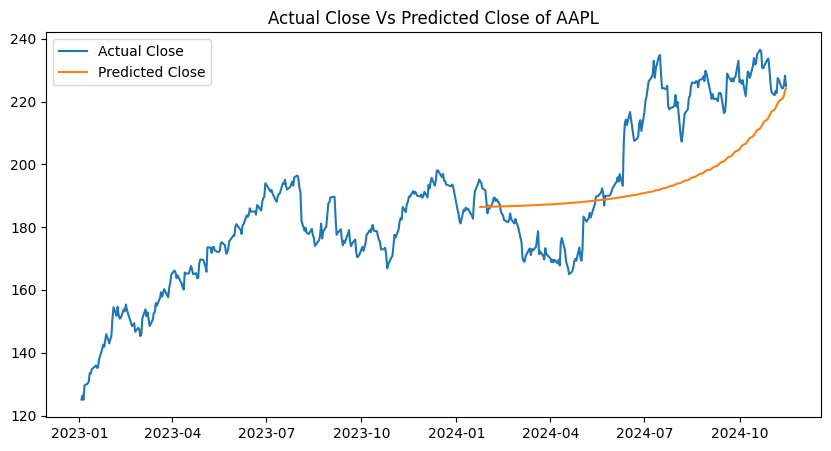

In [184]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(apple_stock_23.index, apple_stock_23['Close'], label='Actual Close')
plt.plot(predictions_df.index, predictions_df['Close'], label = 'Predicted Close')
plt.title('Actual Close Vs Predicted Close of AAPL')
plt.legend()
plt.show()

In [185]:
from statsmodels.tsa.statespace.varmax import VARMAX

varmax_model = VARMAX(train_apple_23.diff(+30).dropna(), order=(6,0), enforce_stationarity=True).fit(disp=False)
varmax_model.summary()

Dep. Variable:,"['Open_AAPL', 'Volume_AAPL', 'Close_AAPL']",No. Observations:,235
Model:,VAR(6),Log Likelihood,-5311.640
,+ intercept,AIC,10749.281
Date:,"Sat, 16 Nov 2024",BIC,10967.234
Time:,21:35:12,HQIC,10837.150
Sample:,0,,
,- 235,,
Covariance Type:,opg,,
Ljung-Box (L1) (Q):,"0.04, 0.03, 0.00",Jarque-Bera (JB):,"69.33, 44.92, 0.38"
Prob(Q):,"0.84, 0.86, 0.95",Prob(JB):,"0.00, 0.00, 0.83"
Heteroskedasticity (H):,"1.36, 0.75, 0.83",Skew:,"0.05, -0.38, 0.05"


In [186]:
n_steps = 14
predict = varmax_model.get_prediction(start=len(train_apple_23),end=len(train_apple_23) + n_steps-1)

varmax_predictions=predict.predicted_mean
varmax_predictions

,Open_AAPL,Volume_AAPL,Close_AAPL
265,5.447345,-1.953787e+06,5.452356
266,5.498545,-1.977064e+06,5.500199
267,5.546996,-1.999126e+06,5.545530
268,5.592892,-2.020071e+06,5.588440
269,5.636326,-2.039818e+06,5.629041
270,5.677434,-2.058526e+06,5.667488
271,5.716362,-2.076269e+06,5.703887
272,5.753207,-2.093030e+06,5.738334
273,5.788083,-2.108872e+06,5.770947
274,5.821102,-2.123899e+06,5.801824


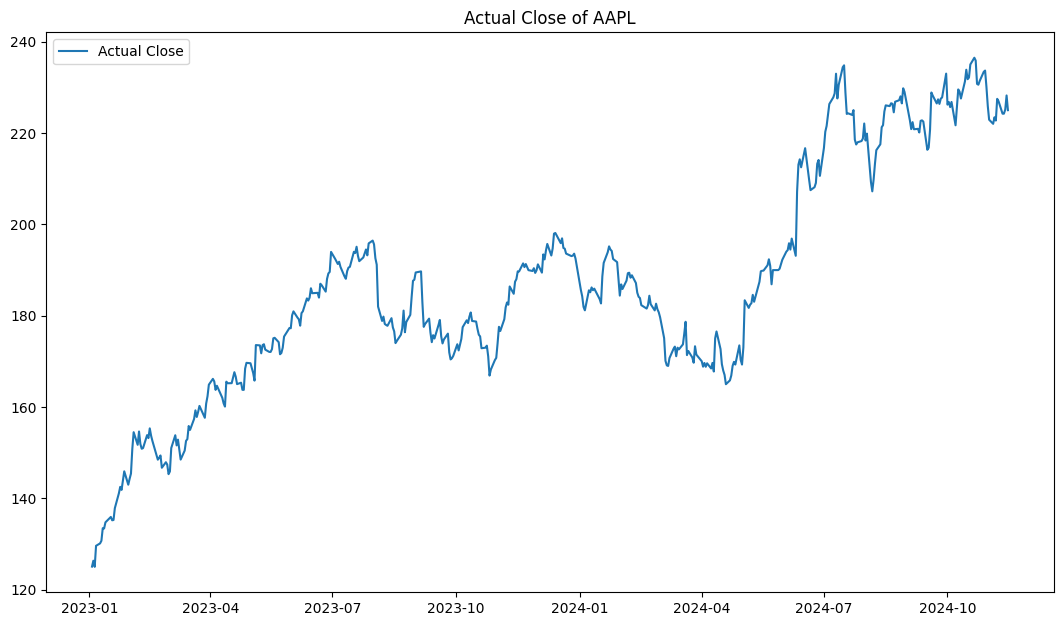

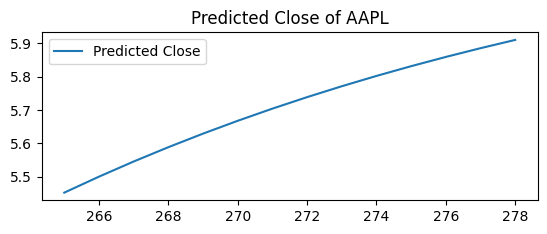

<Figure size 640x480 with 0 Axes>

In [187]:
import matplotlib.pyplot as plt

plt.figure(figsize=(13,16))

plt.subplot(211)
plt.plot(apple_stock_23.index, apple_stock_23['Close'], label='Actual Close')
plt.title('Actual Close of AAPL')
plt.legend()
plt.show()

plt.subplot(212)
plt.plot(varmax_predictions.index, varmax_predictions['Close_AAPL'], label = 'Predicted Close')
plt.title('Predicted Close of AAPL')
plt.legend()
plt.show()

plt.tight_layout()

> *Since stock data is always full of irregularities, so even after differencing and all stationarizing seemingly fails because there're underlying cycles, trends which cannot be removed, even if you does, the data would be white-noise or semi white-noise. These underlying cycles and trends are important for stock data analysis.*

> ***One thing to keep in mind, the trends, seasonality, non-linear cycles of certain occurrences are important to signify the trends, either pump-or-dump, bullish/bearish, etc.***

# Smoothing technique

Smoothing data involves reducing the noise or irregularities in a dataset to reveal underlying trends or patterns. This technique is useful when dealing with noisy or erratic data, as it allows for easier interpretation of the data.

There are several methods for smoothing data in Python, including moving averages, Savitzky-Golay filters, and exponential smoothing. Each method has its strengths and weaknesses and can be applied to different types of datasets.

### Data smoothing
Data smoothing is a technique used to remove noise or irregularities from a dataset. It involves creating a new dataset that represents the original data in a smoother way. The main objective of data smoothing is to identify patterns or trends in the data by reducing the noise or random fluctuations that can obscure them.

There are several methods available for data smoothing such as moving average, Savitzky-Golay filter, and exponential smoothing. Each method has its own advantages and disadvantages depending on the type of data and the desired level of smoothing.

The moving average method calculates the average of a set of values over a specified window size. This method is useful for removing high-frequency noise from the data but may not be effective for removing low-frequency noise.

The Savitzky-Golay filter is a polynomial smoothing technique that fits a polynomial function to a subset of adjacent data points. This method is effective for removing both high-frequency and low-frequency noise from the data.

Exponential smoothing is another popular technique used for time series analysis. It involves assigning weights to past observations in such a way that more recent observations are given greater weight than older ones. This method is particularly useful for forecasting future values based on past trends.

Overall, data smoothing can be a powerful tool for analyzing datasets and identifying underlying patterns or trends. By choosing the appropriate smoothing method for your data, you can improve its accuracy and usefulness for further analysis.

### Rationale of data smoothing
Data smoothing is an essential technique in data analysis that helps to remove noise from data. When working with large datasets, it’s common to have some irregularities or noise that can obscure important trends or patterns in the data. Smoothing techniques help to eliminate these irregularities and provide a clearer picture of the underlying patterns.

Data smoothing is particularly important when dealing with time-series data, where there may be many fluctuations and sudden changes over time. By applying smoothing techniques, analysts can better understand the long-term trends in the data and make more accurate predictions about future behavior.

Furthermore, smoothed data can be easier to interpret and communicate to others. By removing noise and highlighting important trends, smoothed data can help to tell a more compelling story about the insights that can be drawn from the data.

Overall, data smoothing is an essential tool for any analyst who wants to gain deeper insights into their data and make more informed decisions based on that information.

### Types of Data Smoothing Techniques
Data smoothing is a technique used to remove noise from a data set, allowing for easier identification of trends and patterns. There are several types of data smoothing techniques, each with its own strengths and weaknesses. In this section, we will explore the most common types of data smoothing techniques used in Python.

#### Moving Average
The moving average technique involves calculating the average of a subset of data points within a specified window size. The window size determines how many data points are included in the calculation. Moving averages are useful for identifying trends in data sets as they smooth out fluctuations in the data.

Here is an example of how to implement moving averages in Python:

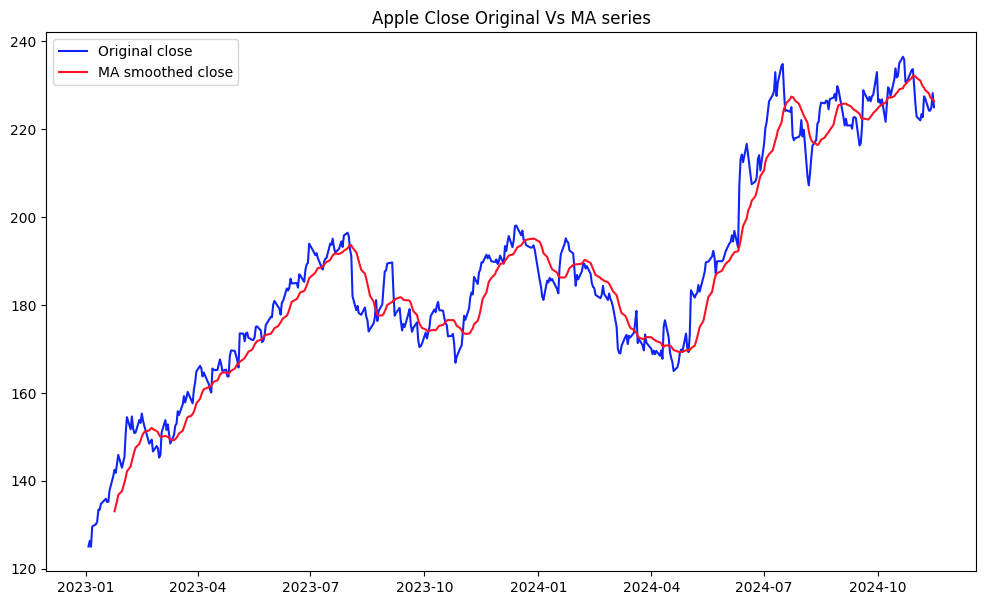

In [188]:
import matplotlib.pyplot as plt

# Using apple stock data from 2023
plt.figure(figsize=(12,7))
plt.plot(apple_stock_23.index, apple_stock_23['Close'], linestyle='-', color='#1124F6', label = 'Original close')
plt.plot(apple_stock_23['Close'].rolling(window=15).mean(), linestyle='-', color='#FF1126', label='MA smoothed close')
plt.title('Apple Close Original Vs MA series')
plt.legend()
plt.show()

#### Simple smoothing
Holt-Winters Simple Exponential Smoothing (often referred to as single smoothing) is a forecasting method for time series data that assumes no trend or seasonality in the data. It uses a weighted average of past observations, where more recent observations are given higher weights, controlled by a smoothing parameter \( \alpha \) (0 ≤ \( \alpha \) ≤ 1).

The formula for updating the level at time \( t \) is:

\[
L_t = \alpha Y_t + (1 - \alpha) L_{t-1}
\]

- **\( L_t \)**: Smoothed value (level) at time \( t \)
- **\( Y_t \)**: Observed value at time \( t \)
- **\( \alpha \)**: Smoothing parameter

It is ideal for data without trends or seasonality and helps reduce noise while capturing the overall pattern of the series.

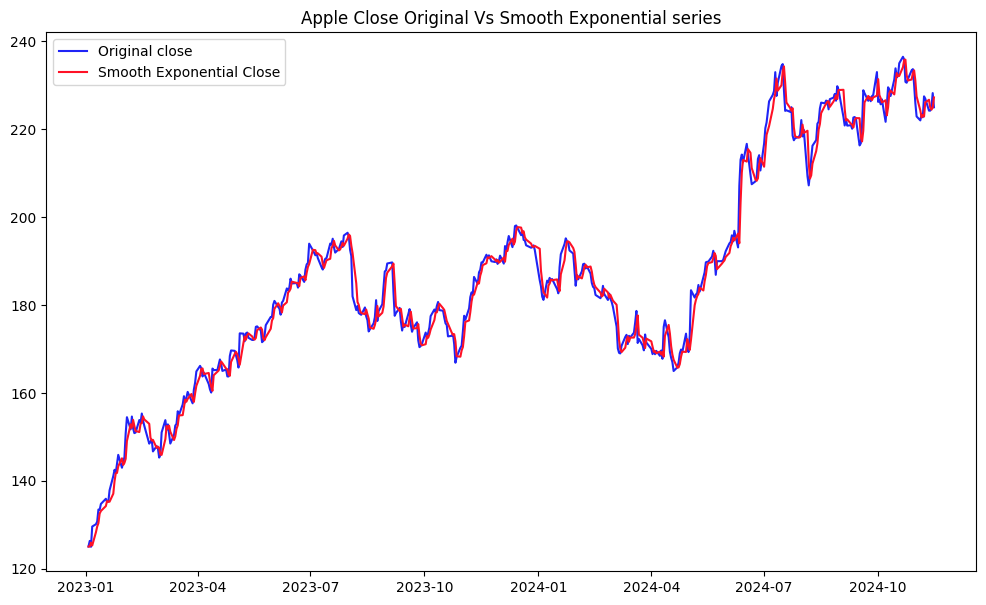

In [189]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
import matplotlib.pyplot as plt

# Using apple stock data from 2023
simple_exp = SimpleExpSmoothing(endog=apple_stock_23['Close']['AAPL']).fit(smoothing_level=0.7)
predictions_smooth = simple_exp.fittedvalues

plt.figure(figsize=(12,7))
plt.plot(apple_stock_23.index, apple_stock_23['Close'], linestyle='-', color='#1F24F6', label = 'Original close')
plt.plot(predictions_smooth, linestyle='-', color='#FF1126', label='Smooth Exponential Close')
plt.title('Apple Close Original Vs Smooth Exponential series')
plt.legend()
plt.show()

##### Prediction using simple exponential smooth

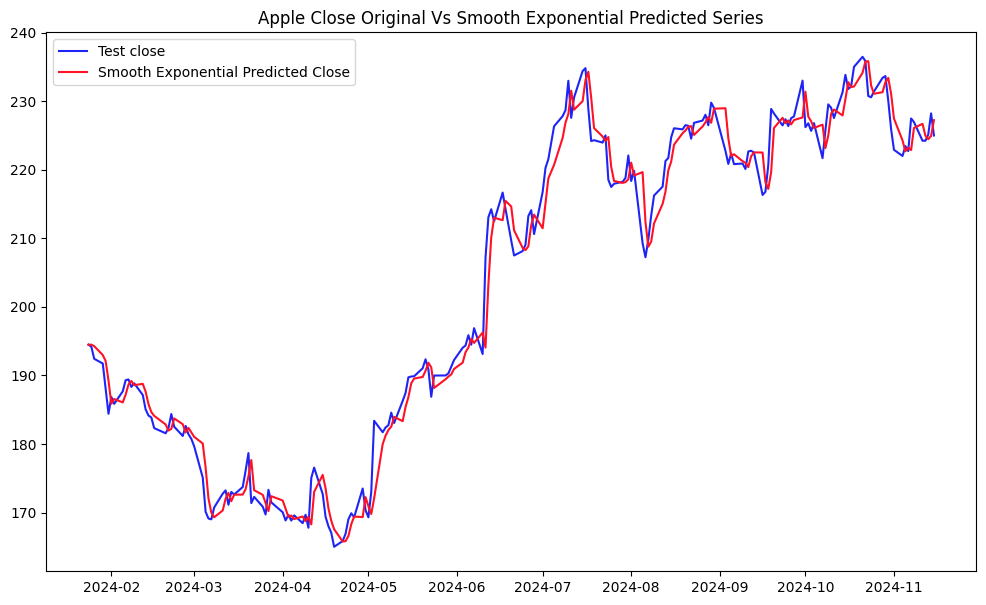

,simple_exp_predict
Date,
2024-01-24 00:00:00+00:00,194.459910
2024-01-25 00:00:00+00:00,194.487973
2024-01-26 00:00:00+00:00,194.265391
2024-01-29 00:00:00+00:00,192.973616
2024-01-30 00:00:00+00:00,192.103082
...,...
2024-11-11 00:00:00+00:00,226.701157
2024-11-12 00:00:00+00:00,224.971344
2024-11-13 00:00:00+00:00,224.452400


In [190]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
import matplotlib.pyplot as plt

simple_exp_model = SimpleExpSmoothing(endog=train_apple_23['Close']['AAPL']).fit(smoothing_level=0.7)
prediction_simp_exp = simple_exp.predict(start = len(train_apple_23['Close']), end = len(train_apple_23) + len(test_apple_23) - 1)
prediction_simp_exp = prediction_simp_exp.to_frame()
# prediction_simp_exp = prediction_simp_exp[prediction_simp_exp.index == test_apple_23.index]
# prediction_simp_exp.index = apple_stock_23.index
prediction_simp_exp.columns = ['simple_exp_predict']

plt.figure(figsize=(12,7))
plt.plot(test_apple_23.index, test_apple_23['Close'], linestyle='-', color='#1F24F6', label = 'Test close')
plt.plot(prediction_simp_exp, linestyle='-', color='#FF1126', label='Smooth Exponential Predicted Close')
plt.title('Apple Close Original Vs Smooth Exponential Predicted Series')
plt.legend()
plt.show()

prediction_simp_exp

In [191]:
test_apple_23['Close'].mean()

Ticker
AAPL    203.378164
dtype: float64

In [192]:
prediction_simp_exp['simple_exp_predict'].mean()

203.1627807001223

#### Exponential Smoothing
Exponential smoothing is a popular technique for time series forecasting. It involves assigning exponentially decreasing weights to older observations, with more recent observations receiving higher weights. This technique is useful for capturing trends and seasonality in time series data.

Here is an example of how to implement exponential smoothing in Python using the Holt-Winters method:

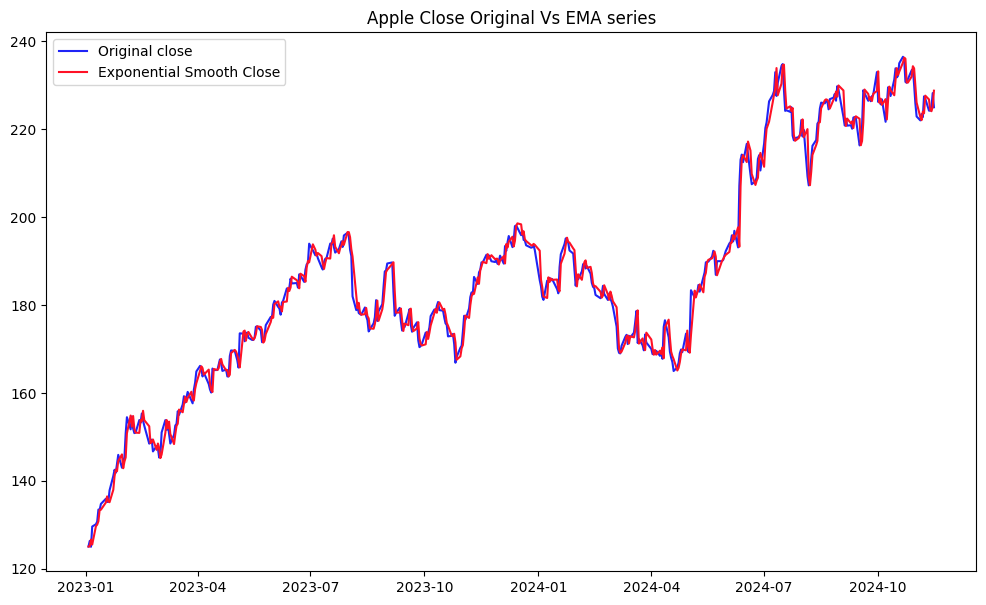

In [193]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt

# Using apple stock data from 2023
exponential_model = ExponentialSmoothing(endog=apple_stock_23['Close'], trend='mul', seasonal='mul', seasonal_periods=7).fit()
predictions = exponential_model.predict(start=0, end=len(apple_stock_23)-1)

plt.figure(figsize=(12,7))
plt.plot(apple_stock_23.index, apple_stock_23['Close'], linestyle='-', color='#1F24F6', label = 'Original close')
plt.plot(predictions, linestyle='-', color='#FF1126', label='Exponential Smooth Close')
plt.title('Apple Close Original Vs EMA series')
plt.legend()
plt.show()

##### Exponential smoothing for forecasting

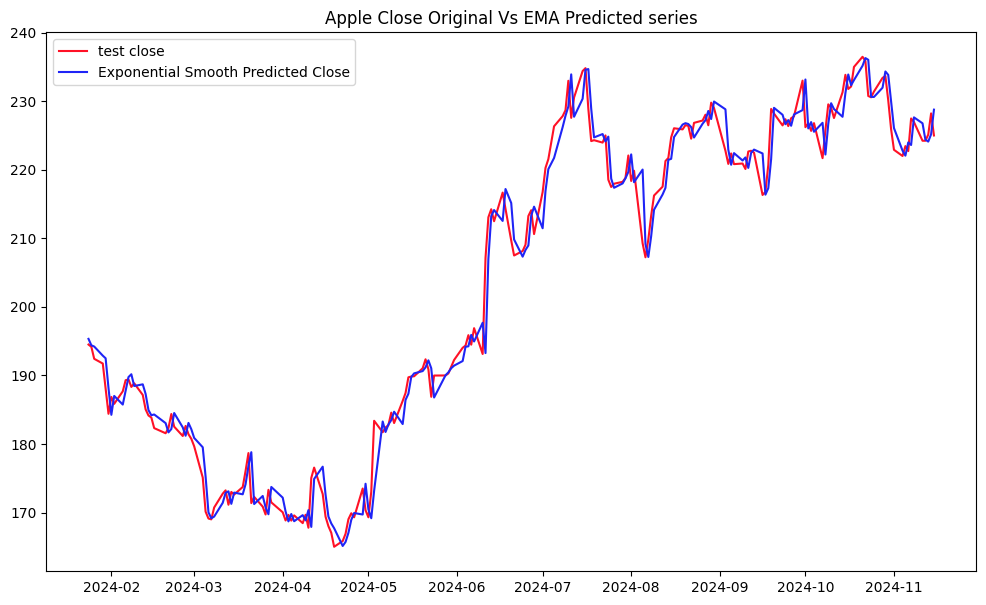

In [194]:
train_exp_model = ExponentialSmoothing(endog=train_apple_23['Close'], trend='mul', seasonal='mul', seasonal_periods=7).fit()
forecast_close = train_exp_model.predict(start=len(train_apple_23), end=len(train_apple_23)+len(test_apple_23)-1)
predictions = predictions.to_frame()
predictions = predictions[predictions.index > split_date]
predictions.columns = ['Predicted Close']
predictions.index = test_apple_23.index

plt.figure(figsize=(12,7))
plt.plot(test_apple_23.index, test_apple_23['Close'], linestyle='-', color='#FF1126', label = 'test close')
plt.plot(predictions.index, predictions['Predicted Close'], linestyle='-', color='#1F24F6', label='Exponential Smooth Predicted Close')
plt.title('Apple Close Original Vs EMA Predicted series')
plt.legend()
plt.show()

In [195]:
predictions

,Predicted Close
Date,
2024-01-24 00:00:00+00:00,195.329575
2024-01-25 00:00:00+00:00,194.391077
2024-01-26 00:00:00+00:00,194.210147
2024-01-29 00:00:00+00:00,192.881797
2024-01-30 00:00:00+00:00,192.497610
...,...
2024-11-11 00:00:00+00:00,226.777543
2024-11-12 00:00:00+00:00,224.401842
2024-11-13 00:00:00+00:00,224.104424


In [196]:
test_apple_23['Close'].mean()

Ticker
AAPL    203.378164
dtype: float64

In [197]:
predictions['Predicted Close'].mean()

203.42801734620565

#### Lowess Smoothing

Lowess smoothing, short for locally weighted scatterplot smoothing, is a non-parametric technique for data smoothing. It involves fitting a regression line to a subset of the data using weighted least squares, with the weights determined by the distance between each point and the point being estimated. This technique is useful for identifying trends and patterns in noisy data.

Here is an example of how to implement lowess smoothing in Python:

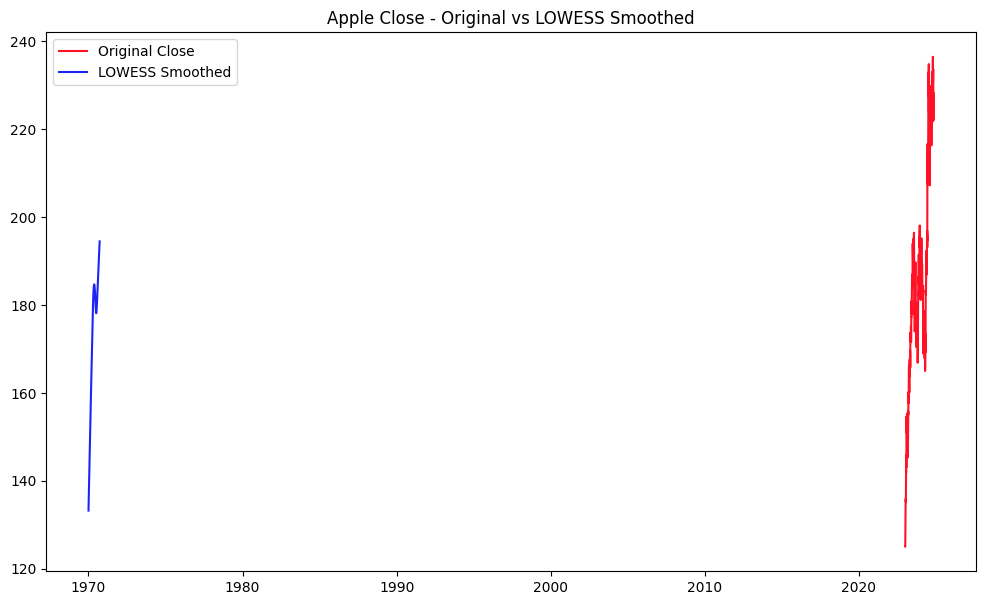

In [198]:
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.pyplot as plt

# Extracting the 'Close' column as a 1D array
lowess_close = lowess(endog=train_apple_23['Close']['AAPL'].values, exog=range(len(train_apple_23['Close']['AAPL'])), frac=0.4)

# Plotting
plt.figure(figsize=(12, 7))
plt.plot(apple_stock_23.index, apple_stock_23['Close'], linestyle='-', color='#FF1126', label='Original Close')
plt.plot(lowess_close[:, 1], linestyle='-', color='#1F24F6', label='LOWESS Smoothed')
plt.title('Apple Close - Original vs LOWESS Smoothed')
plt.legend()
plt.show()

#### Kalman Filtering

Kalman filtering is a recursive algorithm that uses a series of measurements observed over time to estimate unknown variables. It involves predicting the state of a system at time t based on the state at time t-1 and then updating the prediction based on new measurements. This technique is useful for dealing with noisy data and can be used for both linear and non-linear systems.

Here is an example of how to implement Kalman filtering in Python:

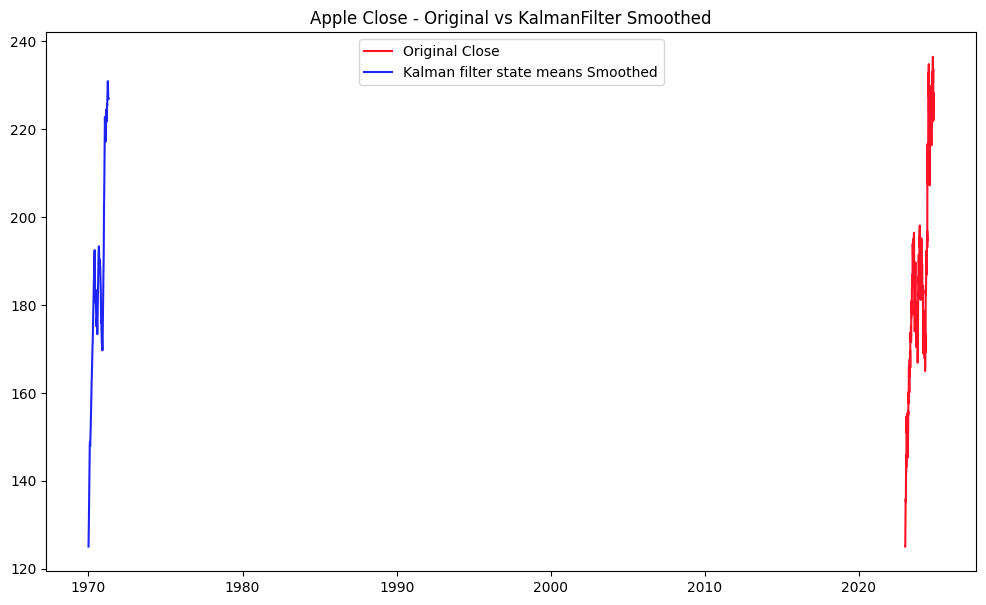

In [199]:
import matplotlib.pyplot as plt
from pykalman import KalmanFilter

kalman_filter = KalmanFilter(
    transition_matrices=[1],
    observation_matrices=[1],
    initial_state_mean=apple_stock_23['Close']['AAPL'].iloc[0],
    initial_state_covariance=1,
    observation_covariance=1,
    transition_covariance=0.01
)

state_means, _ = kalman_filter.filter(apple_stock_23['Close']['AAPL'])
state_means = state_means.flatten()

plt.figure(figsize=(12, 7))
plt.plot(apple_stock_23.index, apple_stock_23['Close'], linestyle='-', color='#FF1126', label='Original Close')
plt.plot(state_means, linestyle='-', color='#1F24F6', label='Kalman filter state means Smoothed')
plt.title('Apple Close - Original vs KalmanFilter Smoothed')
plt.legend(loc= 'upper center')
plt.show()

##### Using `filterpy`

In [200]:

from filterpy.kalman import KalmanFilter
import numpy as np

# Define state transition matrix
F = np.array([[1, 1], [0, 1]])

# Define measurement matrix
H = np.array([[1, 0]])

# Define process noise covariance matrix
Q = np.array([[0.1, 0], [0, 0.01]])

# Define measurement noise covariance matrix
R = np.array([[1]])

# Create Kalman filter object
kf = KalmanFilter(dim_x=2, dim_z=1)
kf.F = F
kf.H = H
kf.Q = Q
kf.R = R

# Initialize state vector and covariance matrix
x0 = np.array([0, 0])
P0 = np.eye(2) * 1000
kf.x = x0
kf.P = P0

# Generate measurements
measurements = [1, 2, 3, 4, 5]

# Perform Kalman filtering
filtered_states = []
for z in measurements:
    kf.predict()
    kf.update(z)
    filtered_states.append(kf.x)

print(filtered_states)

[array([0.99950027, 0.49972515]), array([1.99900518, 0.99791397]), array([2.99950179, 0.99945391]), array([3.99970155, 0.99977055]), array([4.99980229, 0.99987981])]


#### Savitzky-Golay Filtering

Savitzky-Golay filtering is a technique for smoothing noisy data that involves fitting a polynomial to a moving window of data points and then using the coefficients of the polynomial to estimate the smoothed values. This technique is useful for preserving the shape of the data while removing noise.

Here is an example of how to implement Savitzky-Golay filtering in Python:

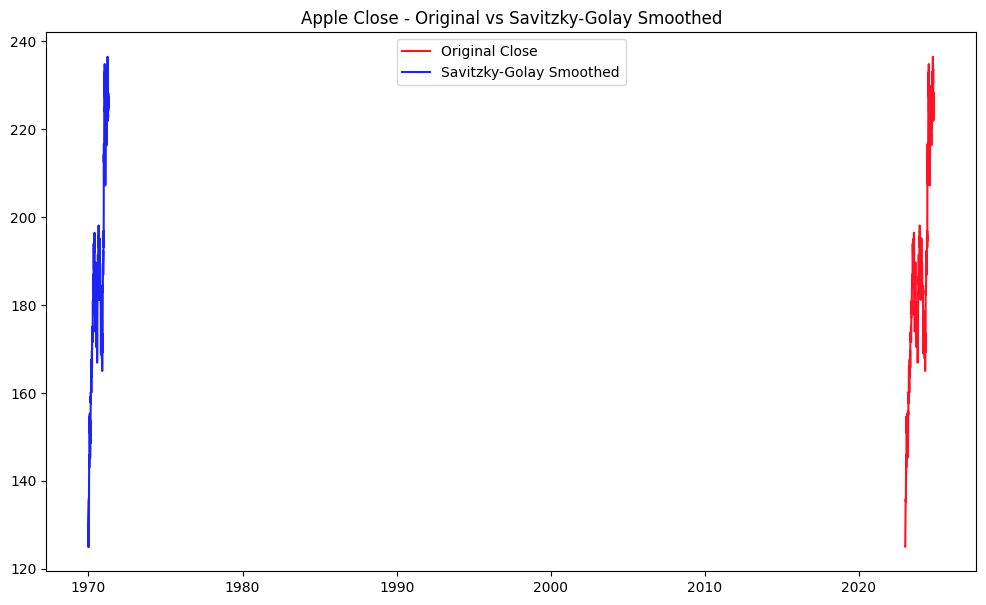

In [201]:
from scipy.signal import savgol_filter

savgol_filtered = savgol_filter(x=apple_stock_23['Close']['AAPL'], window_length=7, polyorder=6)

plt.figure(figsize=(12, 7))
plt.plot(apple_stock_23.index, apple_stock_23['Close'], linestyle='-', color='#FF1126', label='Original Close')
plt.plot(savgol_filtered, linestyle='-', color='#1F24F6', label='Savitzky-Golay Smoothed')
plt.title('Apple Close - Original vs Savitzky-Golay Smoothed')
plt.legend(loc= 'upper center')
plt.show()

# AIC and BIC of forecasting models
For the demo, we'll use only VARMAX fitted model

The lesser they're, the better the model is gonna be.

In [202]:
varmax_model.aic, varmax_model.bic

(10749.280604134194, 10967.234491525276)

# **Data Pre-processing for Time Series Analysis**

## **1. Handling Missing Values**
Missing data in a time series can occur in two ways:
- **Cases**:
  - A date with `null`/`NaN` value: The date is present, but the corresponding value is missing.
  - A date is not present: A time gap where certain dates are entirely absent from the dataset.

- **Methods to Handle Missing Values**:
  - **Imputation**:
    - Replace missing values with statistical measures like **mean**, **median**, or **mode**.
    - Use **forward-fill** (copy the last available value) or **backward-fill** (copy the next available value).
    - Domain-specific constants (e.g., zero in some financial datasets).
  - **Interpolation**:
    - **Linear Interpolation**: Assumes linear progression between missing values.
    - **Spline Interpolation**: Fits a spline curve for smoother interpolation.
    - **Polynomial Interpolation**: Uses higher-degree polynomials to approximate the missing values.
  - **Predictive Modeling**:
    - Train machine learning models (**regression**, **k-nearest neighbors**, **clustering**) to predict missing values based on available data.
    - Utilize specialized time series forecasting methods like ARIMA to infer missing points.

## **2. Making Data Stationary & Handling Outliers**
Stationarity is essential for many time series models like ARIMA and Exponential Smoothing. Outliers can disrupt the signal and model performance.

- **Methods to Ensure Stationarity**:
  - **Moving Average (MA)**: Smoothens the series by averaging over a fixed window, reducing noise and seasonal fluctuations.
  - **Smoothing**:
    - **Exponential Moving Average (EMA)** for weighted smoothing.
    - Seasonal decomposition techniques (e.g., STL) to extract trends and seasonality.
  - **Transformations**:
    - **Log Transformation**: Compresses the scale to reduce variance.
    - **Square Root Transformation**: Reduces extreme spikes.
    - **Box-Cox Transformation**: Flexible transformation that stabilizes variance and normalizes data.

- **Handling Outliers**:
  - Identify outliers using thresholds like the **IQR rule**, **Z-score**, or domain knowledge.
  - Replace outliers with interpolated values, rolling averages, or impute them using models.

## **3. Resampling**
Resampling adjusts the frequency or granularity of a time series to better match the analysis needs.

- **Types of Resampling**:
  - **Up-sampling**:
    - Increase the frequency of the data (e.g., daily to hourly).
    - Fill gaps using interpolation or imputation techniques.
  - **Down-sampling**:
    - Reduce the frequency of the data (e.g., daily to weekly).
    - Aggregate data using statistical measures (e.g., mean, sum, max).

- **Use Cases**:
  - Resampling for aligning datasets with different time frequencies.
  - Converting raw data to meaningful intervals for seasonal or trend analysis.

## **4. Additional Pre-processing Steps**
- **Encoding Cyclic Features**: For datetime features like month, day, or hour, use sine-cosine encoding to capture cyclical patterns.
- **Normalization/Scaling**: Standardize data (e.g., MinMaxScaler, StandardScaler) for models sensitive to scale, like neural networks.
- **Seasonal Decomposition**: Break the series into trend, seasonality, and residual components to better understand its structure.

## **Pre-processing Pipeline for Time Series**
1. Load the data and ensure proper **datetime indexing**.
2. Handle missing values using appropriate techniques.
3. Perform **stationarity tests** (ADF test, KPSS test) and transformations if necessary.
4. Detect and handle outliers.
5. Resample data to match the desired frequency.
6. Normalize or scale data if required.
7. Decompose the series if needed to separate trends and seasonality.

This structured approach ensures the data is clean, consistent, and ready for modeling or analysis.

---
Here's the code demo of each concept

ADF Statistic: -1.6837381867958157
p-value: 0.43950992631604413
Box-Cox Lambda: 1.125491790115182


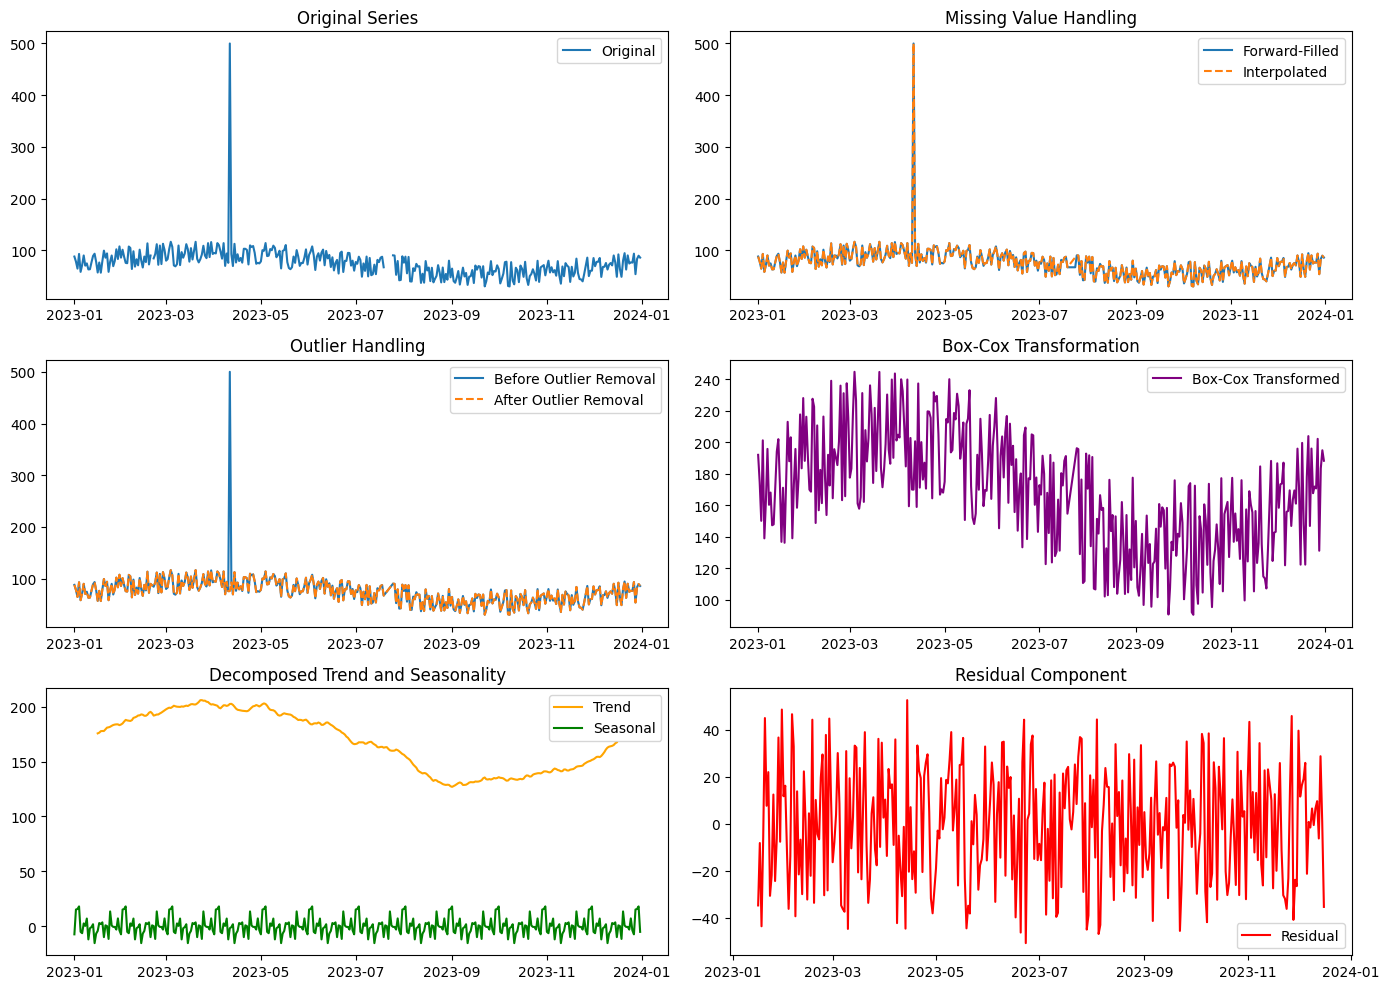

In [204]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import boxcox
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Create synthetic time series data
np.random.seed(42)
date_rng = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')
data = np.random.randint(50, 100, size=(len(date_rng))) + np.sin(np.linspace(0, 3.14 * 2, len(date_rng))) * 20

# Introduce missing values and outliers
data[50] = np.nan  # Missing value
data[100] = 500    # Outlier
data[200:205] = np.nan  # Multiple missing values

time_series = pd.DataFrame({'Date': date_rng, 'Value': data})
time_series.set_index('Date', inplace=True)

# Step 1: Handle missing values
# Imputation using forward-fill
time_series['Value_ffill'] = time_series['Value'].fillna(method='ffill')

# Imputation using linear interpolation
time_series['Value_interpolated'] = time_series['Value'].interpolate(method='linear')

# Step 2: Handle outliers
# Replace outliers with the median of the series
threshold = 3  # Example threshold for outlier detection using z-score
median_value = time_series['Value_interpolated'].median()
time_series['Value_outlier_removed'] = np.where((time_series['Value_interpolated'] - median_value).abs() > threshold * median_value,
                                                median_value,
                                                time_series['Value_interpolated'])

# Step 3: Apply Box-Cox Transformation
# Ensure no zeros or negative values (Box-Cox requires strictly positive data)
time_series['Value_positive'] = time_series['Value_outlier_removed'] + abs(time_series['Value_outlier_removed'].min()) + 1
time_series['Value_boxcox'], boxcox_lambda = boxcox(time_series['Value_positive'])

# Step 4: Seasonal decomposition
# Decompose the Box-Cox transformed series
decomposition = seasonal_decompose(time_series['Value_boxcox'], model='additive', period=30)
time_series['Trend'] = decomposition.trend
time_series['Seasonal'] = decomposition.seasonal
time_series['Residual'] = decomposition.resid

# Step 5: Stationarity Test
# Perform ADF Test on Box-Cox transformed data
result = adfuller(time_series['Value_boxcox'].dropna())
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")
print(f"Box-Cox Lambda: {boxcox_lambda}")

# Step 6: Plot Results
plt.figure(figsize=(14, 10))

# Original series
plt.subplot(3, 2, 1)
plt.plot(time_series.index, time_series['Value'], label='Original')
plt.title('Original Series')
plt.legend()

# Missing value handling
plt.subplot(3, 2, 2)
plt.plot(time_series.index, time_series['Value_ffill'], label='Forward-Filled')
plt.plot(time_series.index, time_series['Value_interpolated'], label='Interpolated', linestyle='--')
plt.title('Missing Value Handling')
plt.legend()

# Outlier handling
plt.subplot(3, 2, 3)
plt.plot(time_series.index, time_series['Value_interpolated'], label='Before Outlier Removal')
plt.plot(time_series.index, time_series['Value_outlier_removed'], label='After Outlier Removal', linestyle='--')
plt.title('Outlier Handling')
plt.legend()

# Box-Cox transformation
plt.subplot(3, 2, 4)
plt.plot(time_series.index, time_series['Value_boxcox'], label='Box-Cox Transformed', color='purple')
plt.title('Box-Cox Transformation')
plt.legend()

# Decomposed components
plt.subplot(3, 2, 5)
plt.plot(time_series.index, time_series['Trend'], label='Trend', color='orange')
plt.plot(time_series.index, time_series['Seasonal'], label='Seasonal', color='green')
plt.title('Decomposed Trend and Seasonality')
plt.legend()

# Residual component
plt.subplot(3, 2, 6)
plt.plot(time_series.index, time_series['Residual'], label='Residual', color='red')
plt.title('Residual Component')
plt.legend()

plt.tight_layout()
plt.show()

ADF Statistic: -1.6383520593150405
p-value: 0.4631220189640597


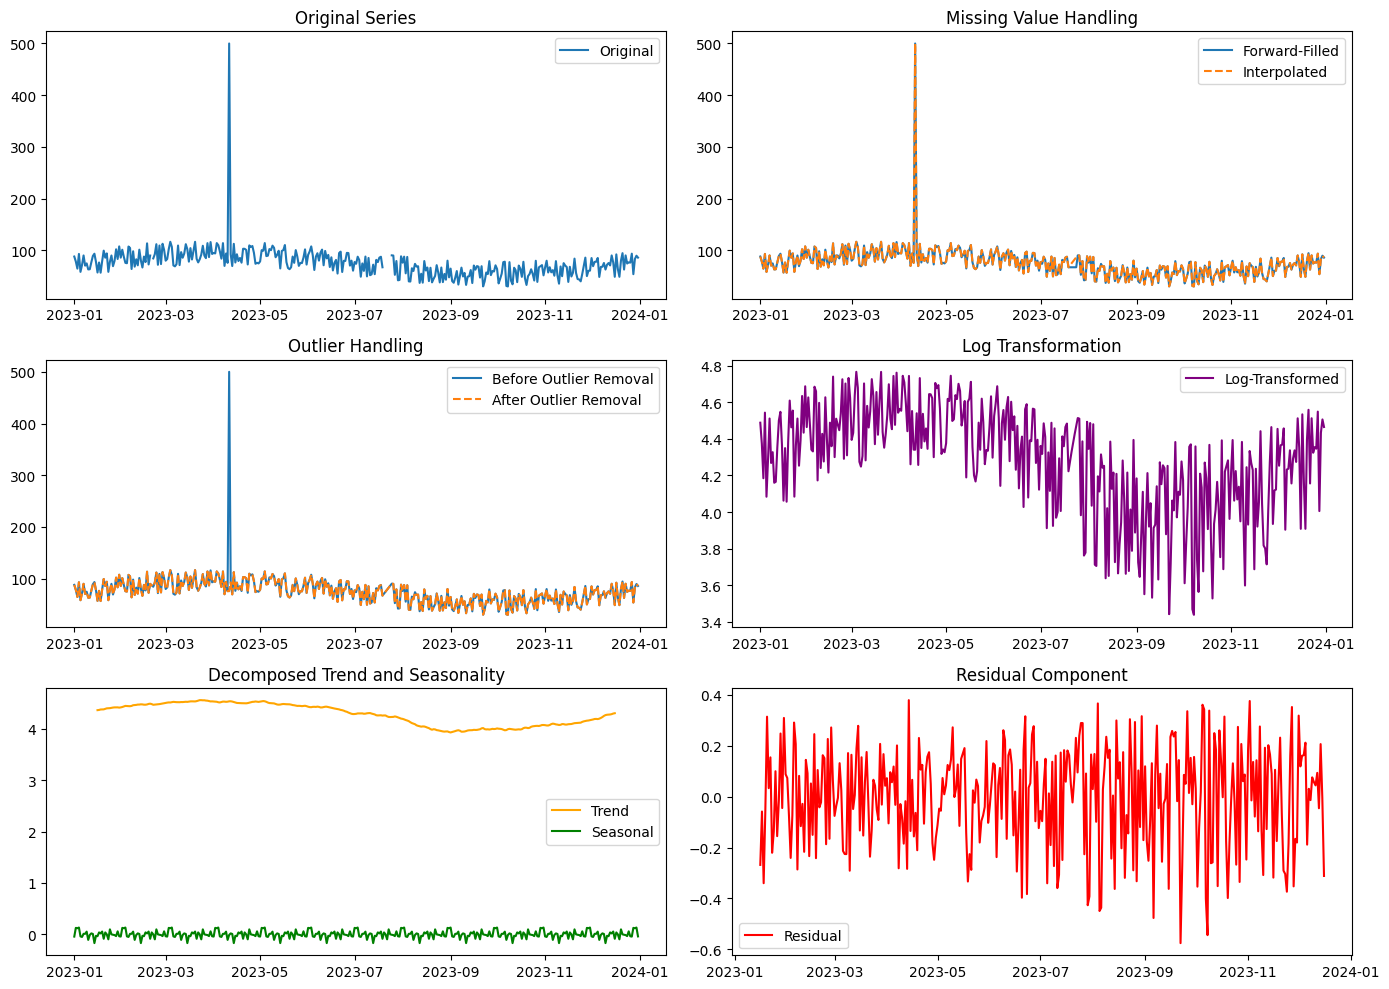

In [205]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Create synthetic time series data
np.random.seed(42)
date_rng = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')
data = np.random.randint(50, 100, size=(len(date_rng))) + np.sin(np.linspace(0, 3.14 * 2, len(date_rng))) * 20

# Introduce missing values and outliers
data[50] = np.nan  # Missing value
data[100] = 500    # Outlier
data[200:205] = np.nan  # Multiple missing values

time_series = pd.DataFrame({'Date': date_rng, 'Value': data})
time_series.set_index('Date', inplace=True)

# Step 1: Handle missing values
# Imputation using forward-fill
time_series['Value_ffill'] = time_series['Value'].fillna(method='ffill')

# Imputation using linear interpolation
time_series['Value_interpolated'] = time_series['Value'].interpolate(method='linear')

# Step 2: Handle outliers
# Replace outliers with the median of the series
threshold = 3  # Example threshold for outlier detection using z-score
median_value = time_series['Value_interpolated'].median()
time_series['Value_outlier_removed'] = np.where((time_series['Value_interpolated'] - median_value).abs() > threshold * median_value,
                                                median_value,
                                                time_series['Value_interpolated'])

# Step 3: Make data stationary (apply log transformation)
time_series['Value_log'] = np.log1p(time_series['Value_outlier_removed'])

# Step 4: Seasonal decomposition
# Decompose the log-transformed series
decomposition = seasonal_decompose(time_series['Value_log'].dropna(), model='additive', period=30)
time_series['Trend'] = decomposition.trend
time_series['Seasonal'] = decomposition.seasonal
time_series['Residual'] = decomposition.resid

# Step 5: Stationarity Test
# Perform ADF Test
result = adfuller(time_series['Value_log'].dropna())
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")

# Step 6: Plot Results
plt.figure(figsize=(14, 10))

# Original series
plt.subplot(3, 2, 1)
plt.plot(time_series.index, time_series['Value'], label='Original')
plt.title('Original Series')
plt.legend()

# Missing value handling
plt.subplot(3, 2, 2)
plt.plot(time_series.index, time_series['Value_ffill'], label='Forward-Filled')
plt.plot(time_series.index, time_series['Value_interpolated'], label='Interpolated', linestyle='--')
plt.title('Missing Value Handling')
plt.legend()

# Outlier handling
plt.subplot(3, 2, 3)
plt.plot(time_series.index, time_series['Value_interpolated'], label='Before Outlier Removal')
plt.plot(time_series.index, time_series['Value_outlier_removed'], label='After Outlier Removal', linestyle='--')
plt.title('Outlier Handling')
plt.legend()

# Log transformation
plt.subplot(3, 2, 4)
plt.plot(time_series.index, time_series['Value_log'], label='Log-Transformed', color='purple')
plt.title('Log Transformation')
plt.legend()

# Decomposed components
plt.subplot(3, 2, 5)
plt.plot(time_series.index, time_series['Trend'], label='Trend', color='orange')
plt.plot(time_series.index, time_series['Seasonal'], label='Seasonal', color='green')
plt.title('Decomposed Trend and Seasonality')
plt.legend()

# Residual component
plt.subplot(3, 2, 6)
plt.plot(time_series.index, time_series['Residual'], label='Residual', color='red')
plt.title('Residual Component')
plt.legend()

plt.tight_layout()
plt.show()

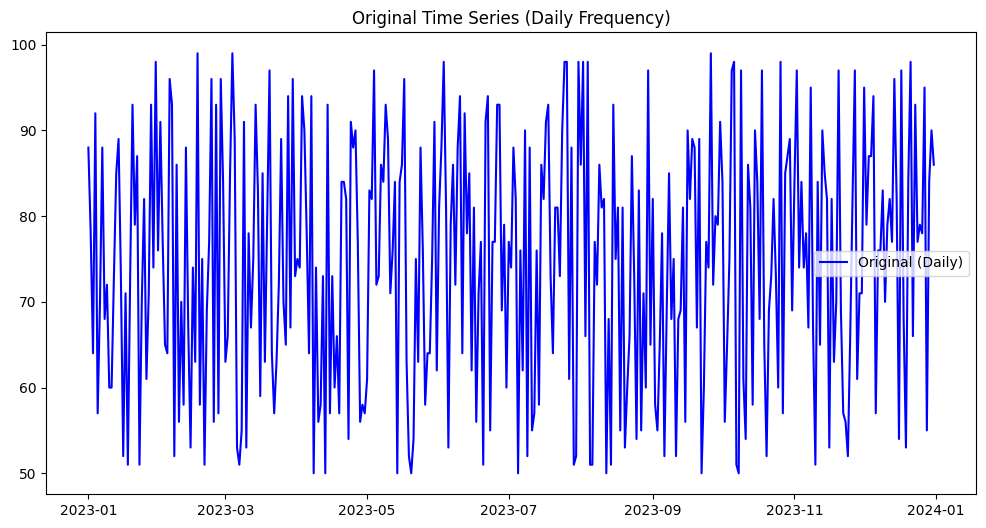

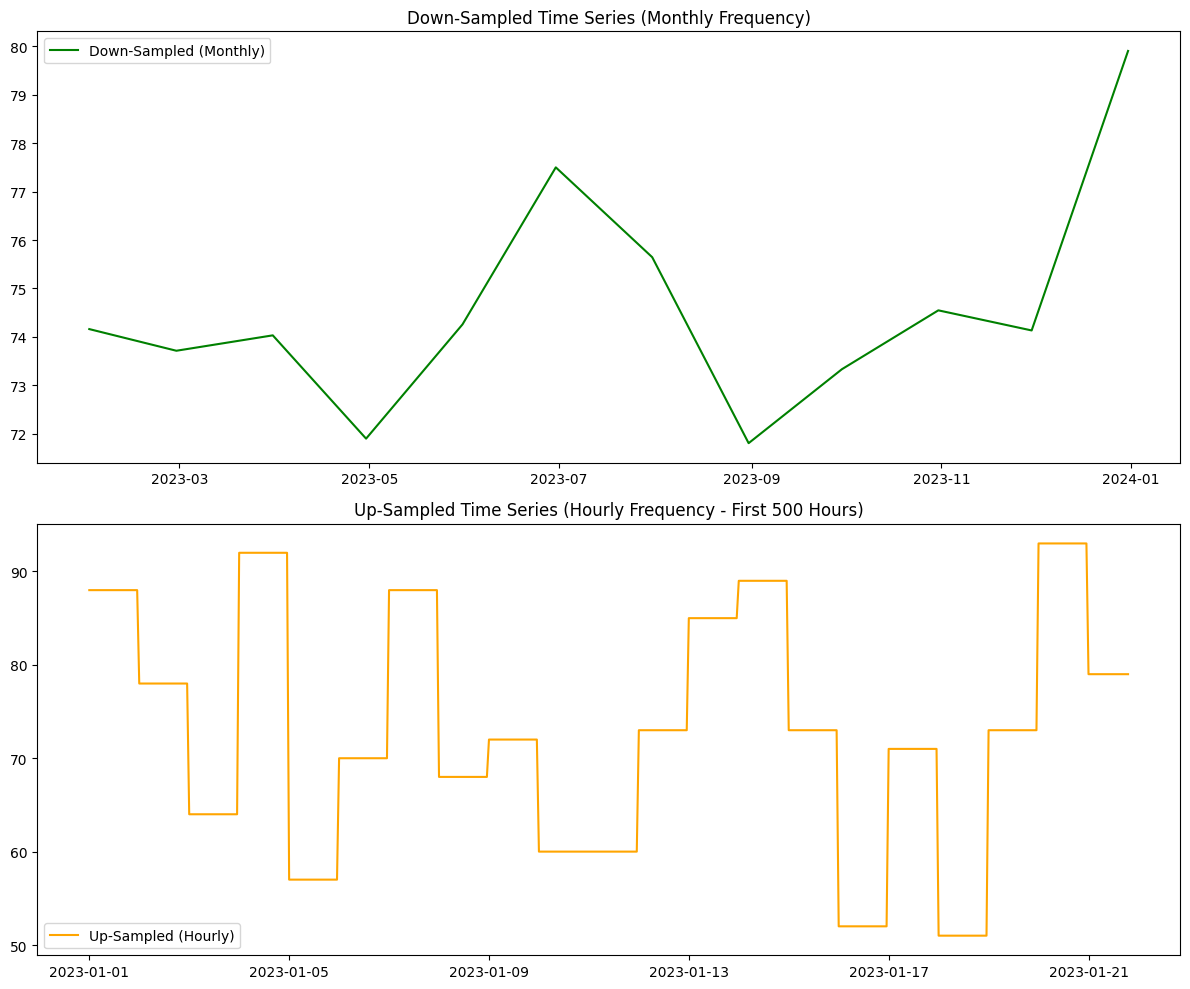

Original Time Series:
            Value
Date             
2023-01-01     88
2023-01-02     78
2023-01-03     64
2023-01-04     92
2023-01-05     57

Down-Sampled Time Series (Monthly):
                Value
Date                 
2023-01-31  74.161290
2023-02-28  73.714286
2023-03-31  74.032258
2023-04-30  71.900000
2023-05-31  74.258065

Up-Sampled Time Series (Hourly):
                     Value
Date                      
2023-01-01 00:00:00     88
2023-01-01 01:00:00     88
2023-01-01 02:00:00     88
2023-01-01 03:00:00     88
2023-01-01 04:00:00     88


In [206]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Generate a synthetic time series dataset
np.random.seed(42)
date_rng = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')  # Daily frequency
data = np.random.randint(50, 100, size=(len(date_rng)))

time_series = pd.DataFrame({'Date': date_rng, 'Value': data})
time_series.set_index('Date', inplace=True)

# Plot the original time series
plt.figure(figsize=(12, 6))
plt.plot(time_series.index, time_series['Value'], label='Original (Daily)', color='blue')
plt.title('Original Time Series (Daily Frequency)')
plt.legend()
plt.show()

# **Down-sampling**: Convert daily data to monthly data (mean of each month)
monthly_resampled = time_series.resample('M').mean()

# **Up-sampling**: Convert daily data to hourly data (forward-fill to fill missing values)
hourly_resampled = time_series.resample('H').ffill()

# Plotting resampled data
plt.figure(figsize=(12, 10))

# Down-sampled data
plt.subplot(2, 1, 1)
plt.plot(monthly_resampled.index, monthly_resampled['Value'], label='Down-Sampled (Monthly)', color='green')
plt.title('Down-Sampled Time Series (Monthly Frequency)')
plt.legend()

# Up-sampled data
plt.subplot(2, 1, 2)
plt.plot(hourly_resampled.index[:500], hourly_resampled['Value'][:500], label='Up-Sampled (Hourly)', color='orange')
plt.title('Up-Sampled Time Series (Hourly Frequency - First 500 Hours)')
plt.legend()

plt.tight_layout()
plt.show()

# Display summary statistics
print("Original Time Series:")
print(time_series.head())
print("\nDown-Sampled Time Series (Monthly):")
print(monthly_resampled.head())
print("\nUp-Sampled Time Series (Hourly):")
print(hourly_resampled.head())

| Platform     | Profile Link                                   |
|--------------|-----------------------------------------------|
| LinkedIn     | [Fawad Awan](https://linkedin.com/in//fawad-awan-893a58171) |
| GitHub       | [JackTheProgrammer](https://github.com/JackTheProgrammer)      |
